## DMRG WITH TENPY

In [10]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pickle
import os
from tqdm import tqdm

import tenpy
from tenpy import CouplingMPOModel, SpinHalfSite
import tenpy.linalg.np_conserved as npc
from tenpy.algorithms import dmrg
from tenpy.networks.mps import MPS
from tenpy.models.tf_ising import TFIChain
from tenpy.simulations.measurement import m_energy_MPO
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

np.set_printoptions(precision=5, suppress=True, linewidth=100)
plt.rcParams['figure.dpi'] = 150

def dump_results(pkl_file):
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)

    base = os.path.splitext(pkl_file)[0]
    os.makedirs(base, exist_ok=True)

    with open(f"{base}/info.txt", 'w') as f:
        f.write(f"timestamp:    {data.get('timestamp', 'N/A')}\n")
        f.write(f"task_id:      {data.get('task_id', 'N/A')}\n")
        f.write(f"sweeps:       {data.get('sweeps', 'N/A')}\n")
        f.write(f"final_chi:    {data.get('final_chi', 'N/A')}\n")
        f.write("\nmodel_params:\n")
        for key, val in data.get('model_params', {}).items():
            f.write(f"  {key}: {val}\n")
        f.write("\ndmrg_params:\n")
        for key, val in data.get('dmrg_params', {}).items():
            f.write(f"  {key}: {val}\n")

    with open(f"{base}/E.txt", 'w') as f:
        f.write("# sweep  energy\n")
        for i, e in enumerate(data['E_per_sweep']):
            f.write(f"{i}  {e:.12f}\n")

    with open(f"{base}/S.txt", 'w') as f:
        f.write("# bond_left  bond_right  S\n")
        for i, s in enumerate(data['S']):
            f.write(f"{i}  {i+1}  {s:.12f}\n")

    for name in ['X', 'Y', 'Z']:
        with open(f"{base}/{name}.txt", 'w') as f:
            f.write(f"# site  <Sigma{name.lower()}>\n")
            for i, val in enumerate(data[name]):
                f.write(f"{i}  {val.real:.12f}\n")

    for name in ['XX_corr', 'XY_corr', 'XZ_corr', 'YY_corr', 'YZ_corr', 'ZZ_corr']:
        # C = data[name]
        # L = C.shape[0]
        with open(f"{base}/{name}.txt", 'w') as f:
            f.write(f"# site_j real\n")
            for i, val in enumerate(data[name]):
                f.write(f"{i}  {val.real:.12f}\n")
    
    for name in ['XX', 'XYZ', "XIY"]:
        with open(f"{base}/{name}.txt", 'w') as f:
            f.write(f"# site  <Sigma{name.lower()}>\n")
            for i, val in enumerate(data[name]):
                f.write(f"{i}  {val.real:.12f}\n")


    print(f"Results written to: {base}/")

    # remove the old file
    os.remove(base+".pkl")
    


In [ ]:
class myModel(CouplingMPOModel):
    def init_sites(self, model_params):
        site = SpinHalfSite(conserve=None)
        return site
    
    def init_terms(self, model_params):
        Jx = model_params.get('Jx', 1.0)
        hz = model_params.get('hz', 0.0)
        k  = model_params.get('k', 0.0)

        # Onsite magnetic field
        for u in range(len(self.lat.unit_cell)):
            self.add_onsite(hz, u, 'Sigmaz')

        # Nearest-neighbor XX coupling
        for u1, u2, dx in self.lat.pairs['nearest_neighbors']:
            self.add_coupling(Jx, u1, 'Sigmax', u2, 'Sigmax', dx)

        # 3-site interactions (already Hermitian)
        dx = [(0,), (1,), (2,)]
        u = 0  # single-site unit cell

        self.add_multi_coupling(
            k,
            [('Sigmax', dx[0], u), ('Sigmay', dx[1], u), ('Sigmaz', dx[2], u)]
        )
        self.add_multi_coupling(
            -k,
            [('Sigmay', dx[0], u), ('Id', dx[1], u), ('Sigmax', dx[2], u)]
        )
        self.add_multi_coupling(
            -k,
            [('Sigmaz', dx[0], u), ('Sigmay', dx[1], u), ('Sigmax', dx[2], u)]
        )
        self.add_multi_coupling(
            k,
            [('Sigmax', dx[0], u), ('Id', dx[1], u), ('Sigmay', dx[2], u)]
        )
model_params = {
        'Jx': 1,
        'hz': 0.5,
        'k': 0.2,
        'L': 5,
        'bc_MPS': 'finite'
    }
ham = myModel(model_params)
H = ham.calc_H_MPO()

# Alternative: access internal data structure
print("ONSITE internal:")
print(vars(ham.onsite_terms['Sigmaz']))

print("\nCOUPLING internal:")
print(vars(ham.coupling_terms['Sigmax_i Sigmax_j']))

print("\nMULTI-COUPLING internal:")
print(vars(ham.coupling_terms['Sigmax_i Sigmay_j Sigmaz_k']))

def dmrg_sim(Jx, hz, kl, kr, filename):
    dmrg_params = {
    'mixer': True,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-4,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-10,
    },
    'combine': True,
    'verbose': True
    }

    model_params = {
    'Jx': Jx , 'hz': hz, 'kl': kl, 'kr': kr,
    'L': L,
    'bc_MPS': 'finite',
    }

    M = myModel(model_params)
    psi = MPS.from_lat_product_state(M.lat, [['up']])

    eng = dmrg.TwoSiteDMRGEngine(psi, M, dmrg_params)
    E, psi = eng.run() # the main work; modifies psi in place

    # save to file
    data = {'psi': psi, 'dmrg_params': dmrg_params, 'model_params': model_params}

    os.makedirs(filename, exist_ok=True)
        
    loc = os.path.join(filename, f'{hz:.3f}_{kl:.3f}.pkl')
    with open(loc, 'wb') as f:
        pickle.dump(data, f)
    
    return M

def dmrg_lines(start, stop, step, fixed, filename, setval="k", Jx=1):
    values = np.arange(start, stop+step, step)

    for sweep in values:
        if setval == "k":
            hz = sweep
            k = fixed
        elif setval == "h":
            hz = fixed
            k = sweep

        M = dmrg_sim(Jx, hz, k, k, filename)


ONSITE internal:
{'L': 5, 'onsite_terms': [{'Sigmaz': np.float64(0.5)}, {'Sigmaz': np.float64(0.5)}, {'Sigmaz': np.float64(0.5)}, {'Sigmaz': np.float64(0.5)}, {'Sigmaz': np.float64(0.5)}]}

COUPLING internal:
{'L': 5, 'coupling_terms': {np.int64(0): {('Sigmax', 'Id'): {np.int64(1): {'Sigmax': np.int64(1)}}}, np.int64(1): {('Sigmax', 'Id'): {np.int64(2): {'Sigmax': np.int64(1)}}}, np.int64(2): {('Sigmax', 'Id'): {np.int64(3): {'Sigmax': np.int64(1)}}}, np.int64(3): {('Sigmax', 'Id'): {np.int64(4): {'Sigmax': np.int64(1)}}}}}

MULTI-COUPLING internal:
{'L': 5, 'terms_left': {np.int64(0): {('Sigmax', 'Id'): {-1: [1]}}, np.int64(1): {('Sigmax', 'Id'): {-1: [2]}}, np.int64(2): {('Sigmax', 'Id'): {-1: [3]}}}, 'terms_right': {np.int64(2): {('Sigmaz', 'Id'): {6: [1]}}, np.int64(3): {('Sigmaz', 'Id'): {6: [2]}}, np.int64(4): {('Sigmaz', 'Id'): {6: [3]}}}, 'connections': [None, (np.int64(1), 'Sigmay', np.int64(0), np.float64(0.2)), (np.int64(2), 'Sigmay', np.int64(0), np.float64(0.2)), (np.int64

In [11]:
L = 800
k = 0.5

results = os.path.join(os.getcwd(),"dmrg_results", f"L{L}-full", f"k_{k}")
results_dual = results + "_dual"

for i in os.listdir(results):
    if os.path.splitext(i)[1] == ".pkl":
        dump_results(os.path.join(results, i))
    elif os.path.splitext(i)[1] == ".py":
        os.remove(os.path.join(results, i))
    elif os.path.splitext(i)[1] == ".sh":
        os.remove(os.path.join(results, i))

for i in os.listdir(results_dual):
    if os.path.splitext(i)[1] == ".pkl":
        dump_results(os.path.join(results_dual, i))
    elif os.path.splitext(i)[1] == ".py":
        os.remove(os.path.join(results_dual, i))
    elif os.path.splitext(i)[1] == ".sh":
        os.remove(os.path.join(results_dual, i))



Results written to: /home/silvanita/Desktop/thesis/master_thesis/books/dmrg_results/L800-full/k_0.5/h0.800_0.500/
Results written to: /home/silvanita/Desktop/thesis/master_thesis/books/dmrg_results/L800-full/k_0.5/h1.000_0.500/
Results written to: /home/silvanita/Desktop/thesis/master_thesis/books/dmrg_results/L800-full/k_0.5/h1.200_0.500/
Results written to: /home/silvanita/Desktop/thesis/master_thesis/books/dmrg_results/L800-full/k_0.5/h0.700_0.500/
Results written to: /home/silvanita/Desktop/thesis/master_thesis/books/dmrg_results/L800-full/k_0.5/h1.100_0.500/
Results written to: /home/silvanita/Desktop/thesis/master_thesis/books/dmrg_results/L800-full/k_0.5/h0.900_0.500/
Results written to: /home/silvanita/Desktop/thesis/master_thesis/books/dmrg_results/L800-full/k_0.5_dual/h1.429_0.714/
Results written to: /home/silvanita/Desktop/thesis/master_thesis/books/dmrg_results/L800-full/k_0.5_dual/h1.250_0.625/
Results written to: /home/silvanita/Desktop/thesis/master_thesis/books/dmrg_re

/tmp/ipykernel_72196/373172023.py:3: RuntimeWarning: divide by zero encountered in log10
  err_energy = np.log10(energy - energy[-1])
/tmp/ipykernel_72196/373172023.py:3: RuntimeWarning: invalid value encountered in log10
  err_energy = np.log10(energy - energy[-1])


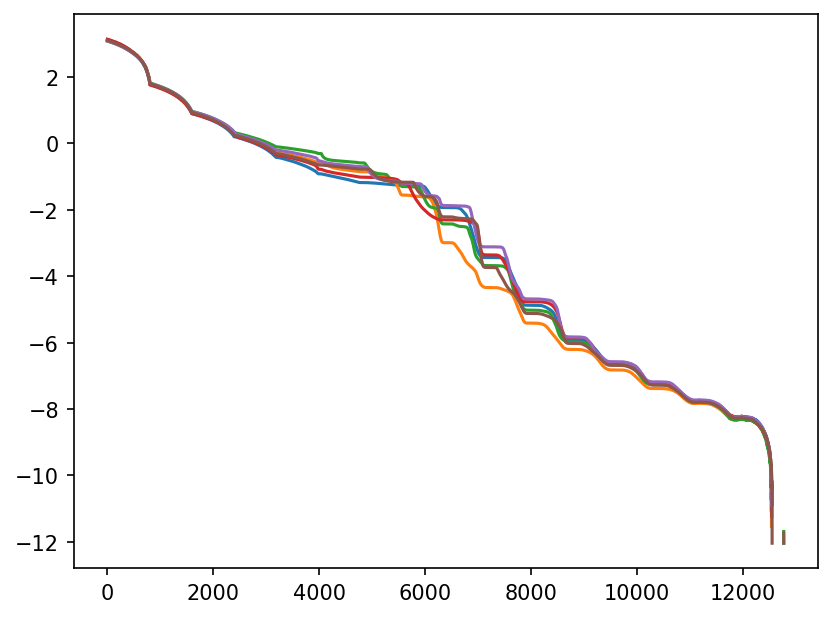

In [12]:
for i in os.listdir(results):
    iter, energy = np.loadtxt(os.path.join(results, i, "E.txt")).T
    err_energy = np.log10(energy - energy[-1])
    plt.plot(iter, err_energy)
plt.show()

## Energy

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 137.31it/s]
/tmp/ipykernel_72196/2898389305.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


[0.7 0.8 0.9 1.  1.1 1.2]


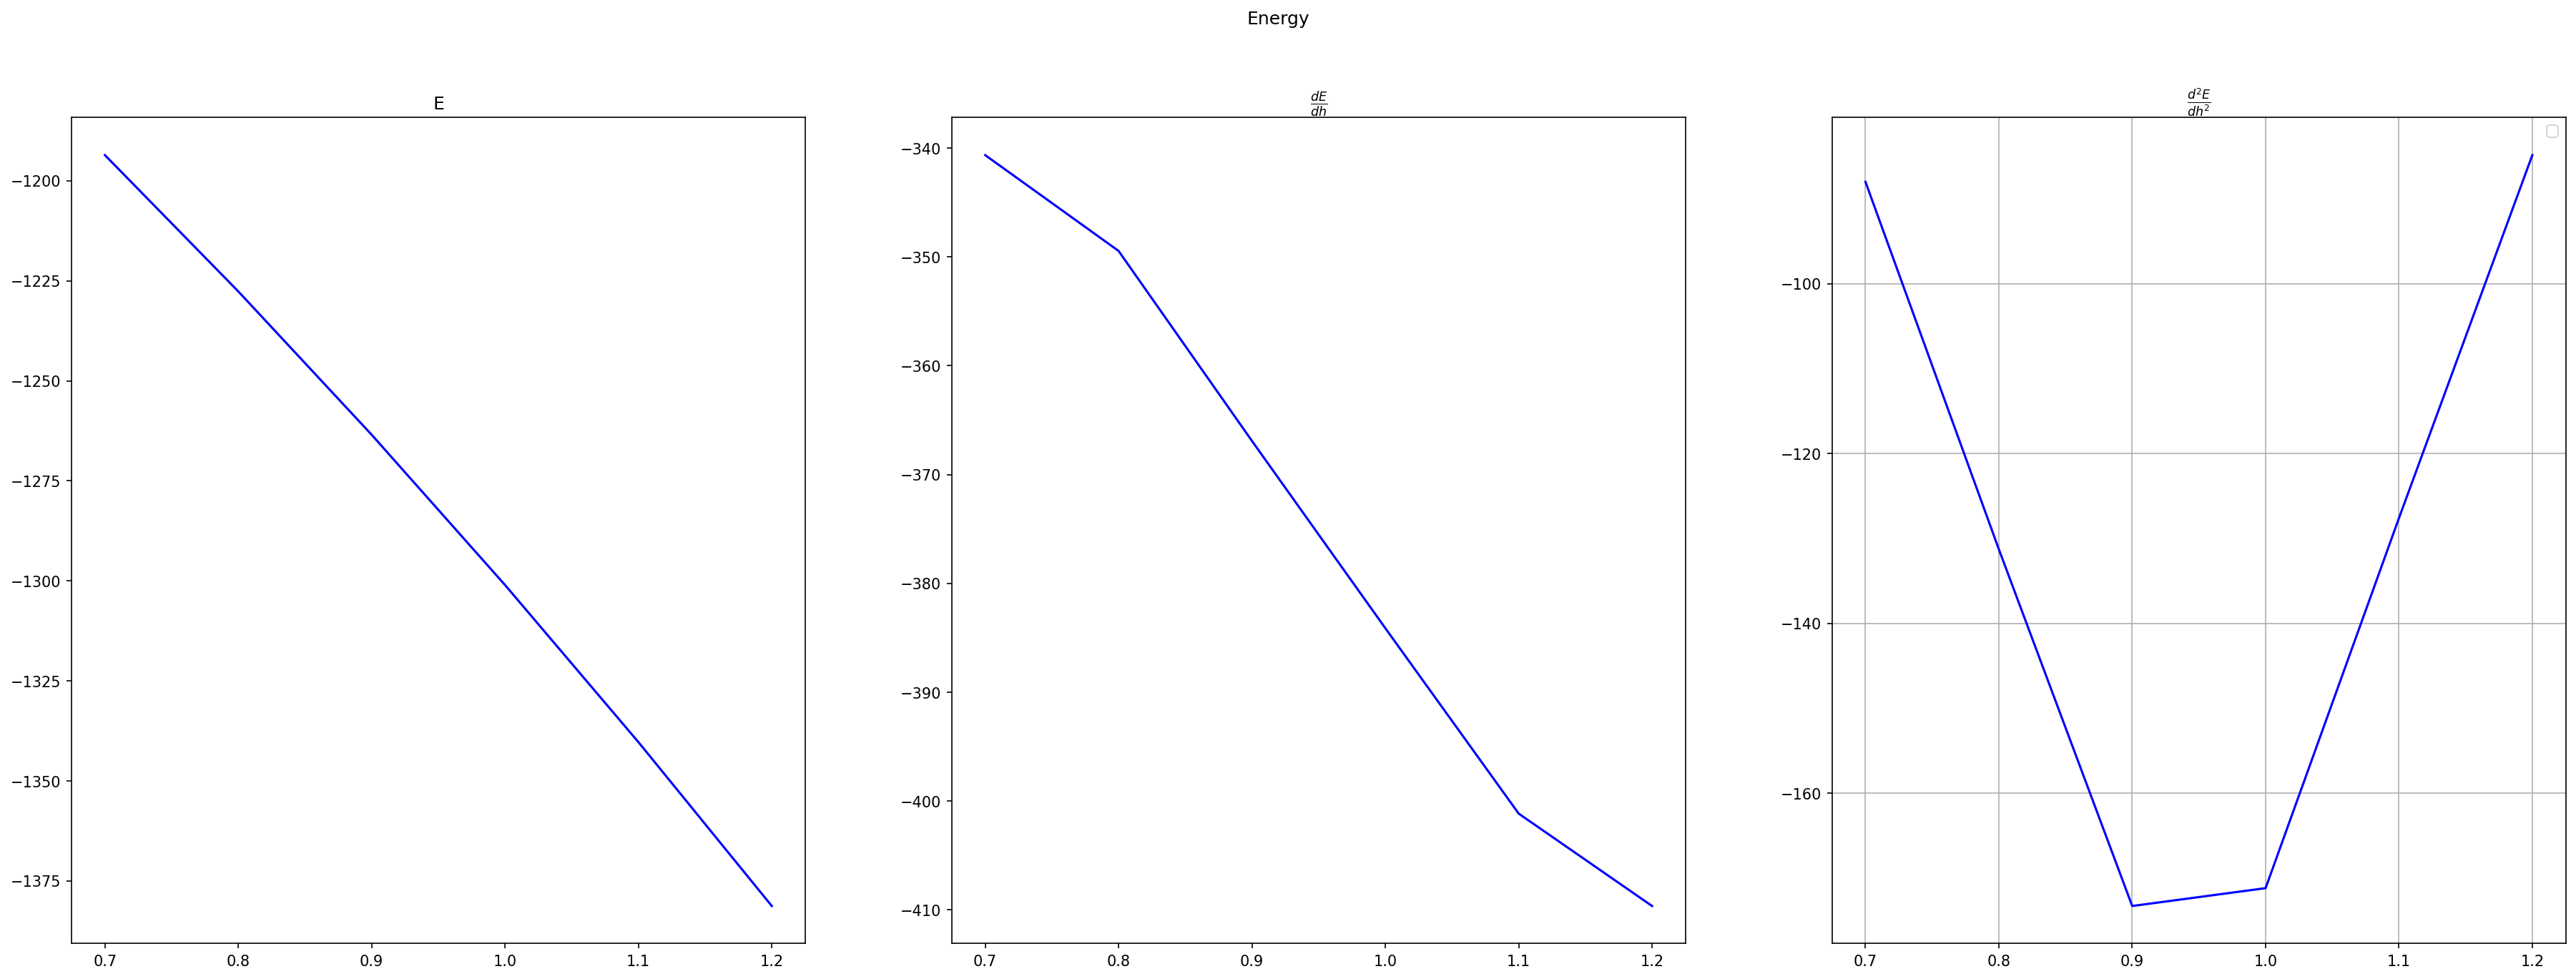

In [13]:
h = [0.5]
slices = [1]
color = ["blue", "red", "green"]

fig, ax = plt.subplots(1, 3, figsize=(30, 10))

# look for energy kink
def find_energy(h, results):
    hs = []
    ks = []
    E = []
    
    for i in tqdm(sorted(os.listdir(results))):
        loc = os.path.join(results, i)
        h, k = i.split("_")
        h = h[1:]
        _, energy = np.loadtxt(os.path.join(loc, "E.txt")).T
            
        E.append(energy[-1])
        hs.append(float(h))
        ks.append(float(k))
    params = np.array([hs, ks])
    return params, E

fig.suptitle("Energy")
for hx, slice, cor in zip(h, slices, color):
    params, E = find_energy(hx, results)
    print(params[0])
    dE_dparam = np.gradient(E, params[0])
    d2E_dparam2 = np.gradient(dE_dparam, params[0])
    ax[0].plot(params[0], E, c=cor)
    ax[1].plot(params[0], dE_dparam, c=cor)
    ax[2].plot(params[0], d2E_dparam2, c=cor)
    ax[0].set_title("E")
    ax[1].set_title(r"$\frac{dE}{dh}$")
    ax[2].set_title(r"$\frac{d^2E}{dh^2}$")

plt.legend()
plt.grid()
plt.show()

## Magnetization Profile

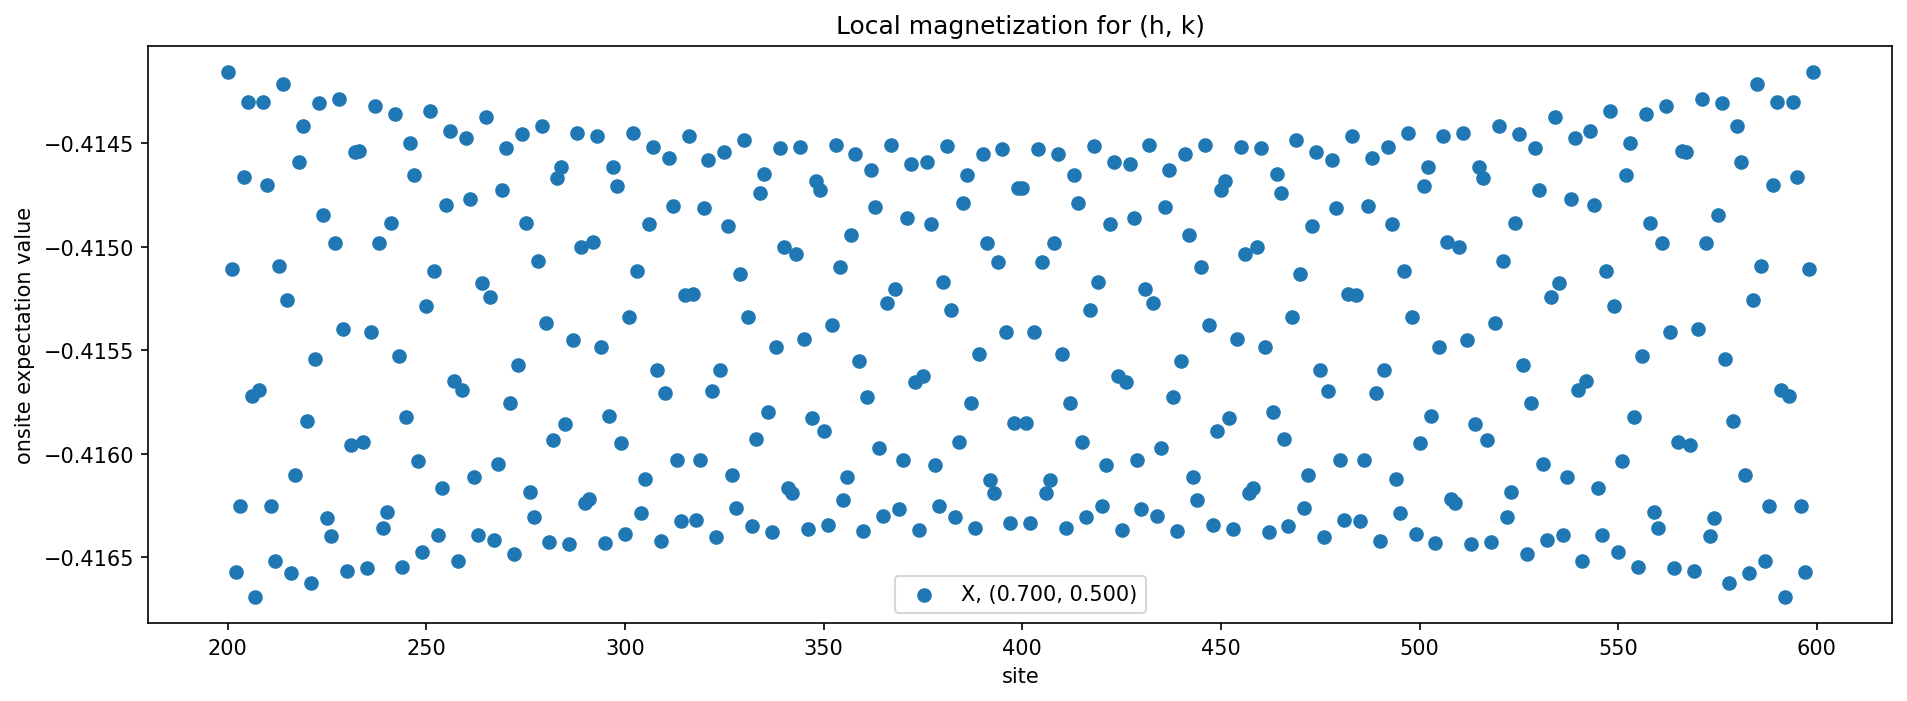

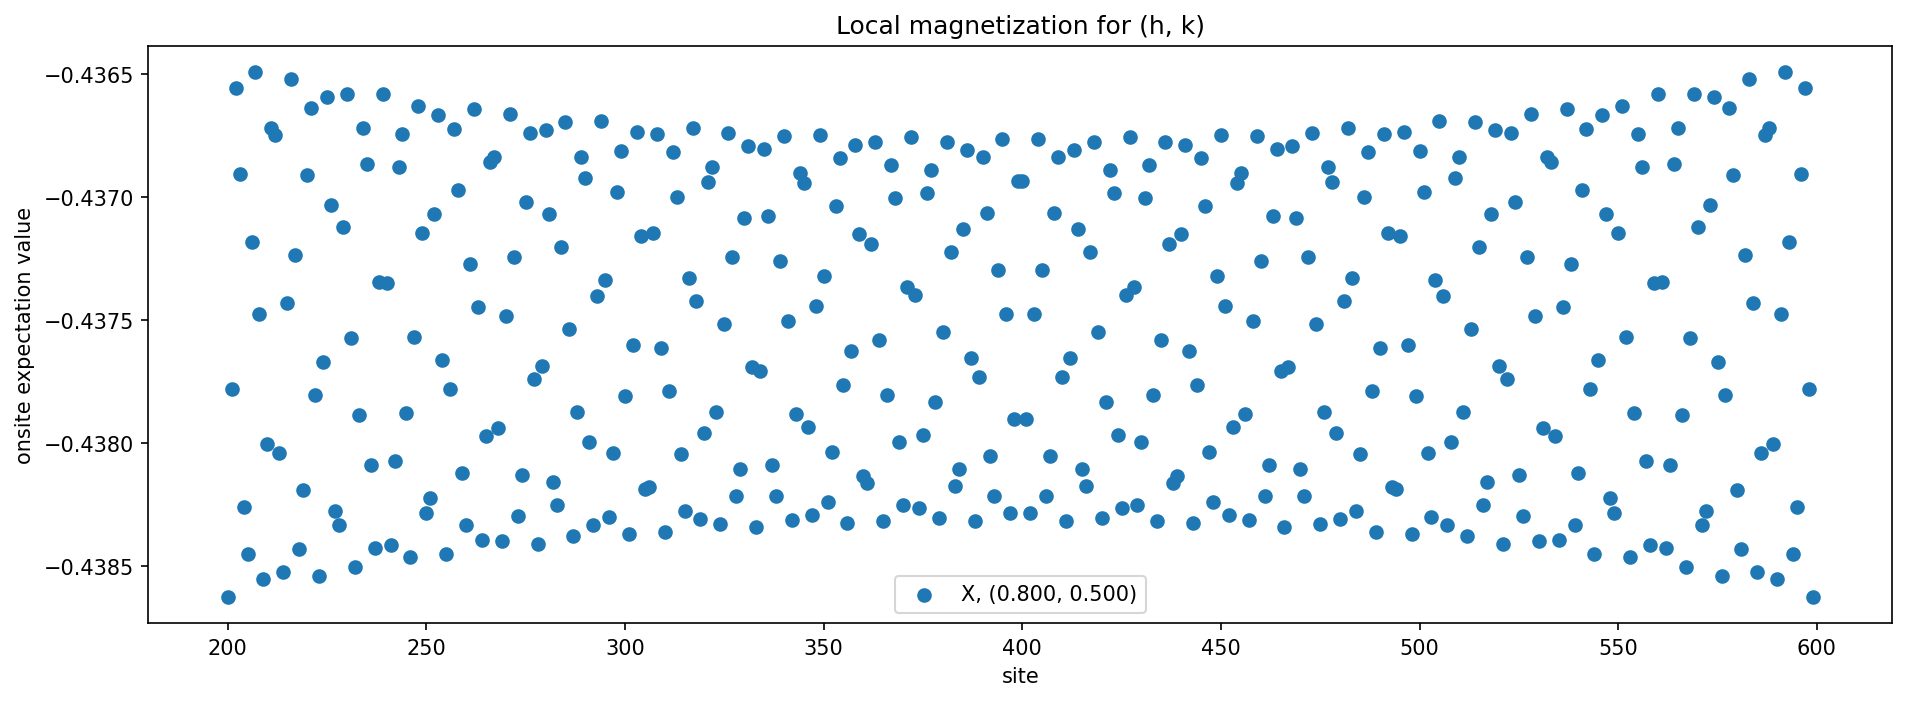

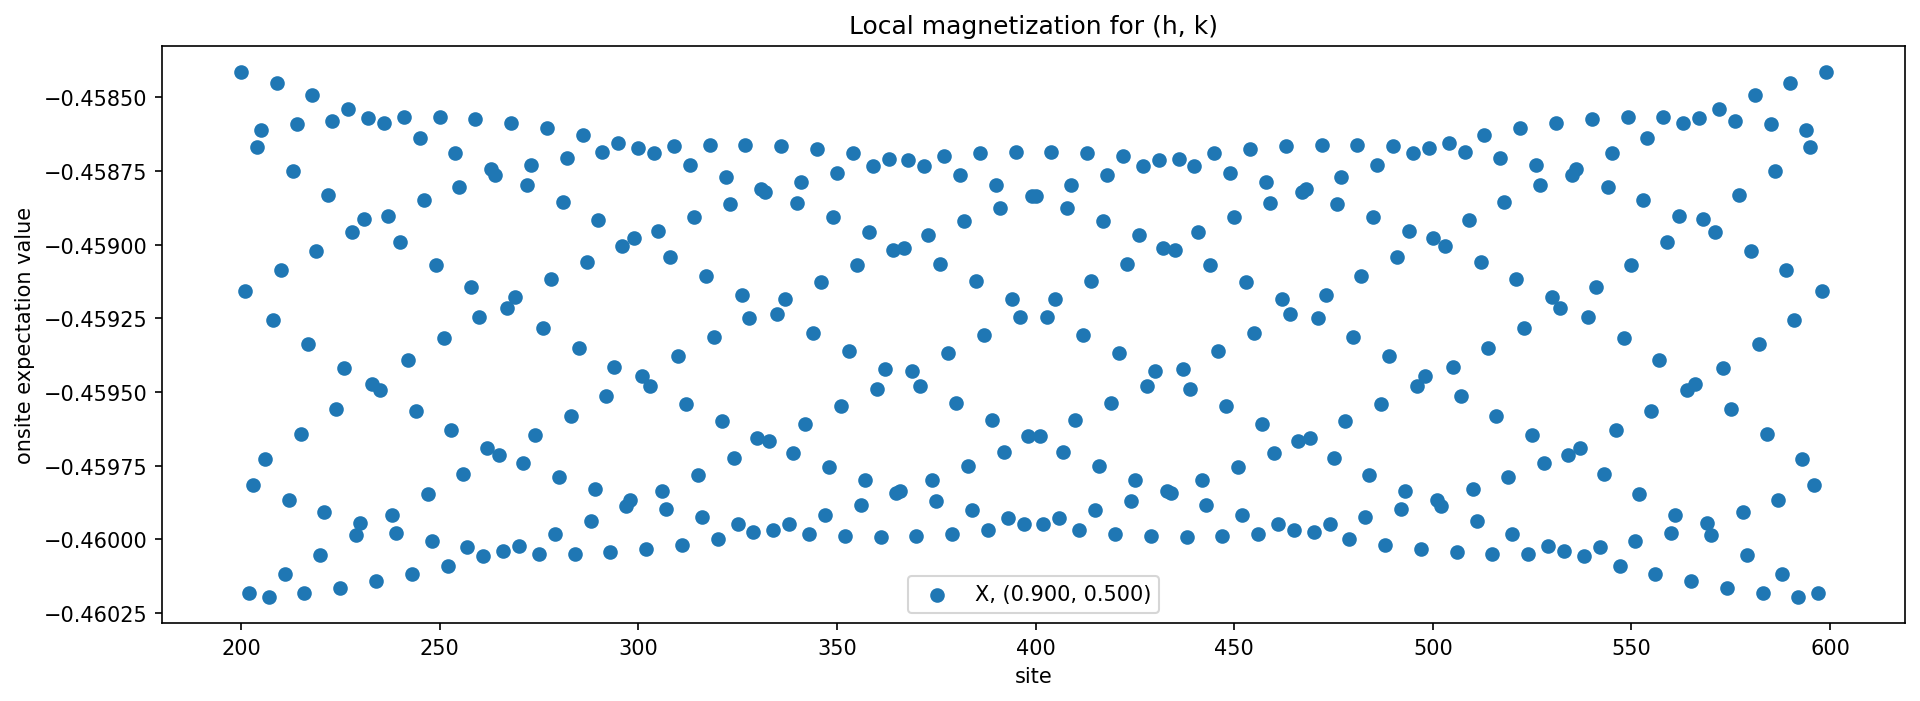

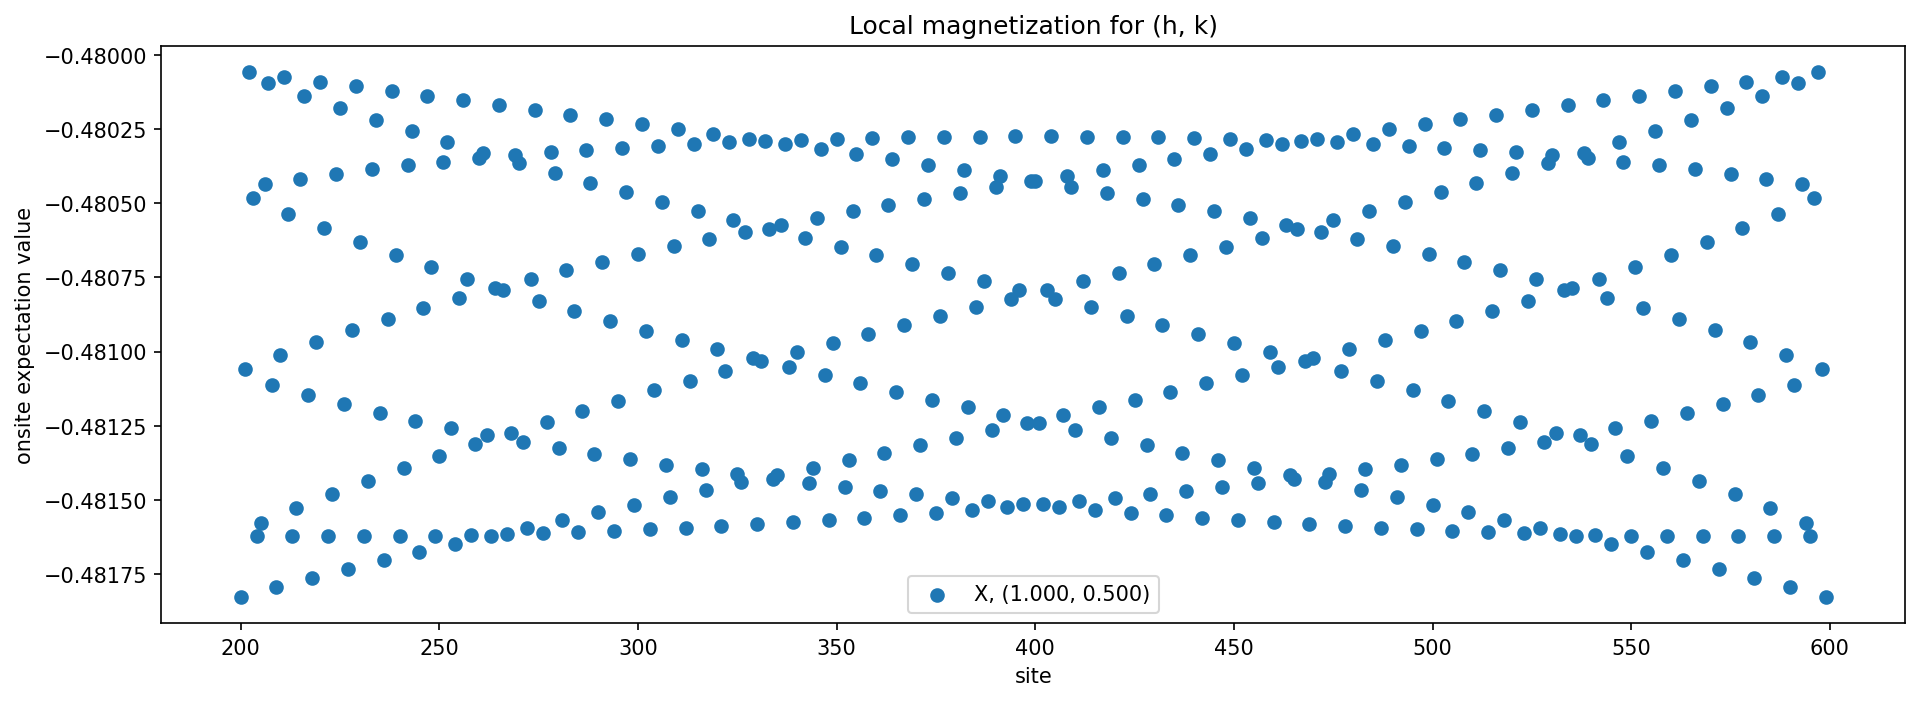

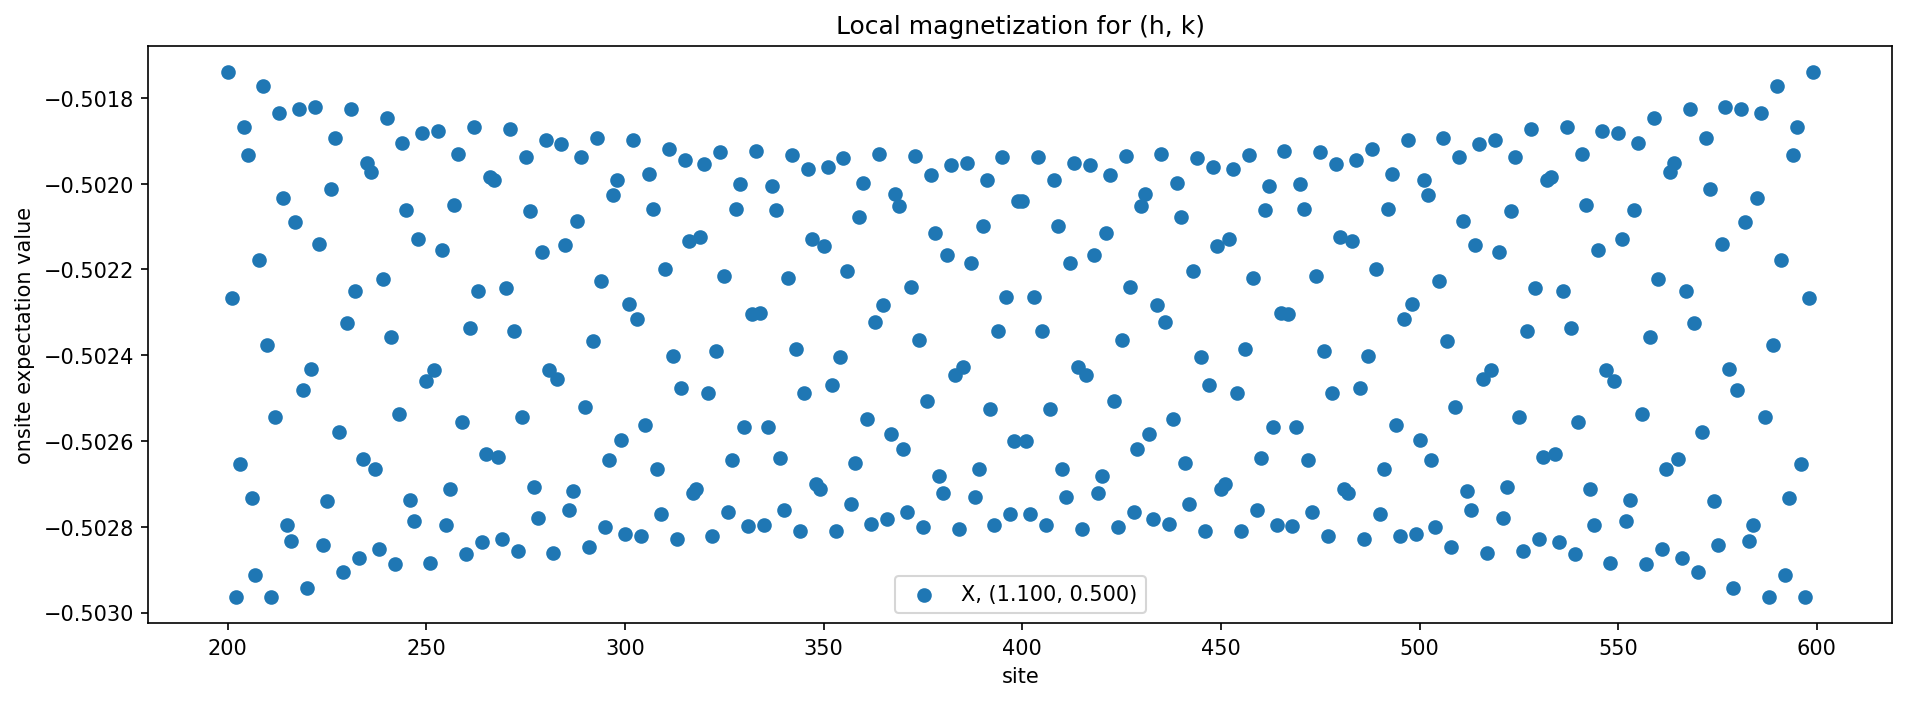

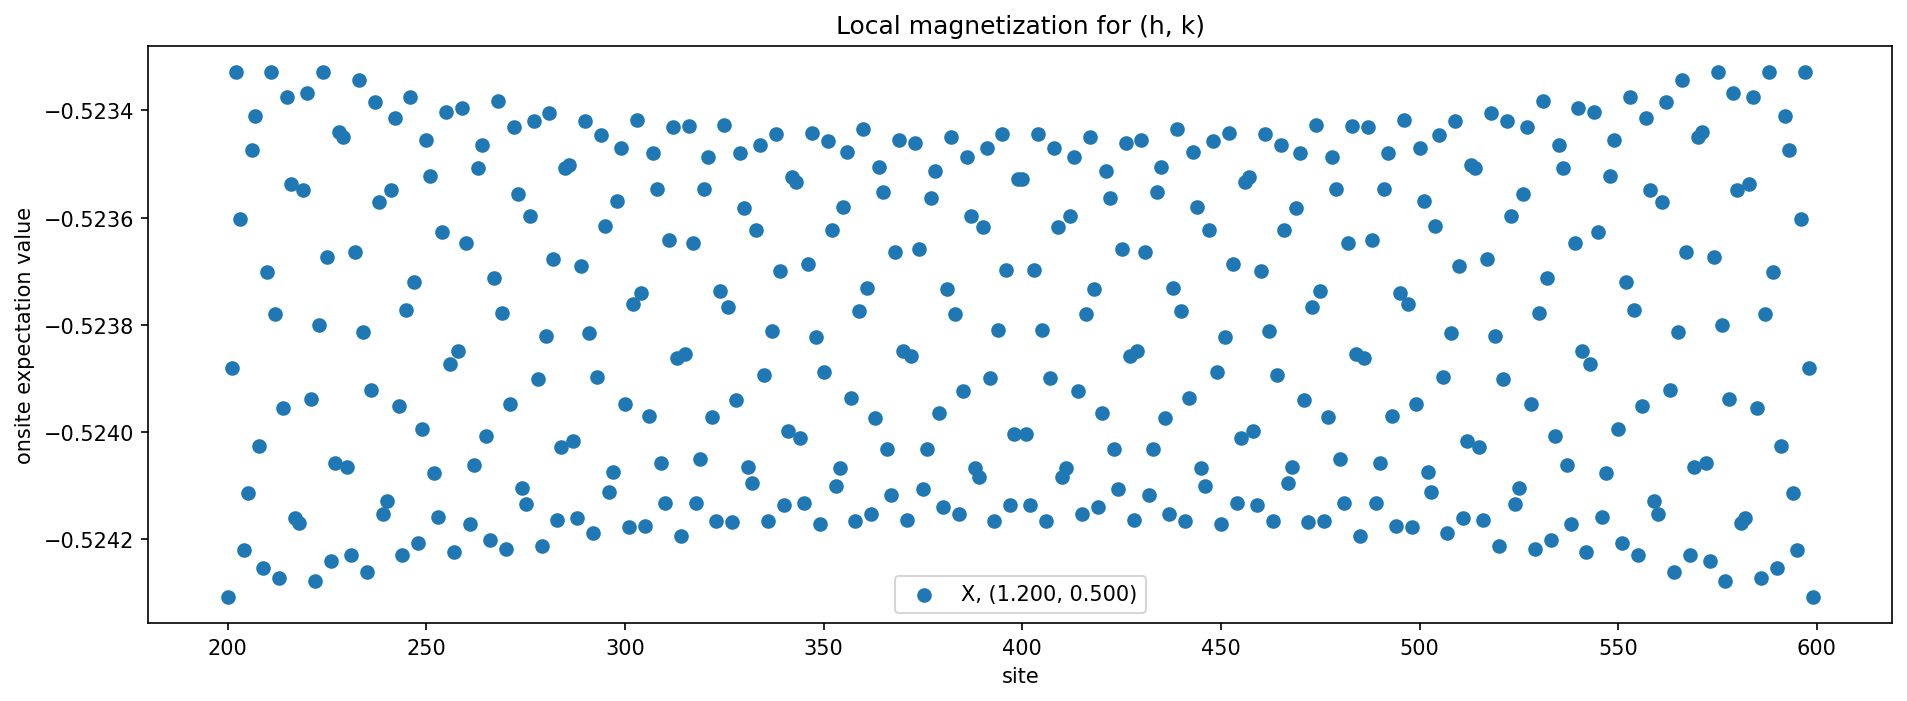

In [27]:
Z = []
par = []

# onsite expectation values
for i in sorted(os.listdir(results)):
    loc = os.path.join(results, i)

    k = i.split("_")[-1]

    h = i.split("_")[0][1:]
    par.append(h)
    x, X = np.loadtxt(os.path.join(loc, "Z.txt")).T

    cut = L//4
    A = np.max(X[cut:-cut]) - np.min(X[cut:-cut])

    Z.append(np.mean(X[cut:-cut]))

    plt.figure(figsize=(15, 5))
    plt.scatter(x[cut:-cut], X[cut:-cut], label=f"X, ({h}, {k})")
    # plt.ylim(-1, 1)
    # plt.axhline(np.max(X[cut:-cut]))
    # plt.axhline(np.min(X[cut:-cut]))
    epsilon = 0.05
    # plt.ylim(-(1+epsilon), (1+epsilon))
    plt.title("Local magnetization for (h, k)")
    plt.xlabel("site")
    plt.ylabel("onsite expectation value")
    plt.legend()
    plt.show()

# plt.scatter(par, Z)

## Duality Check

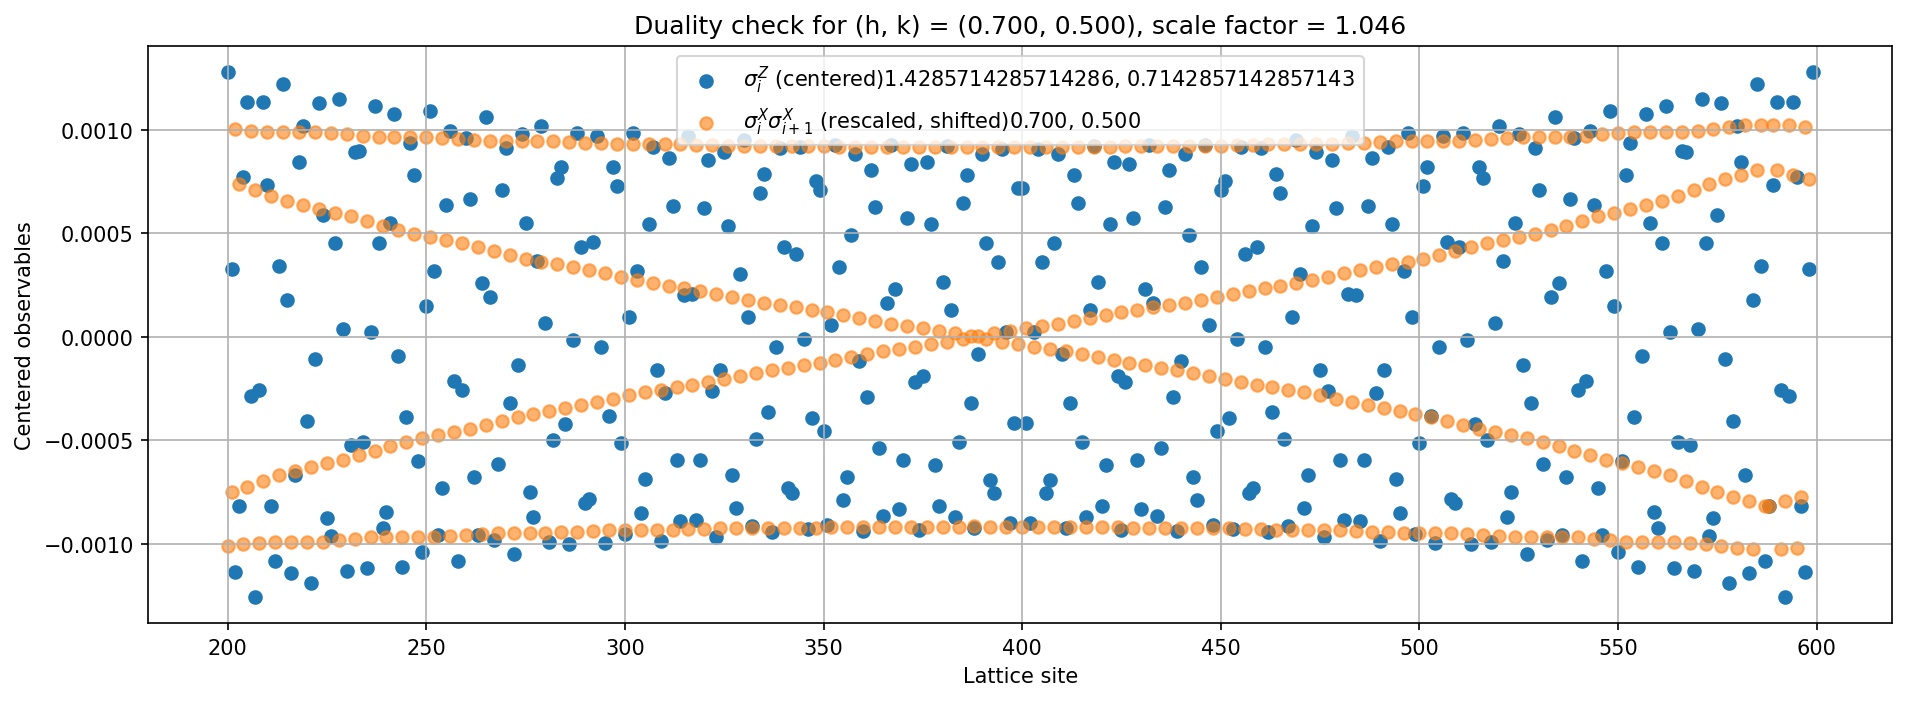

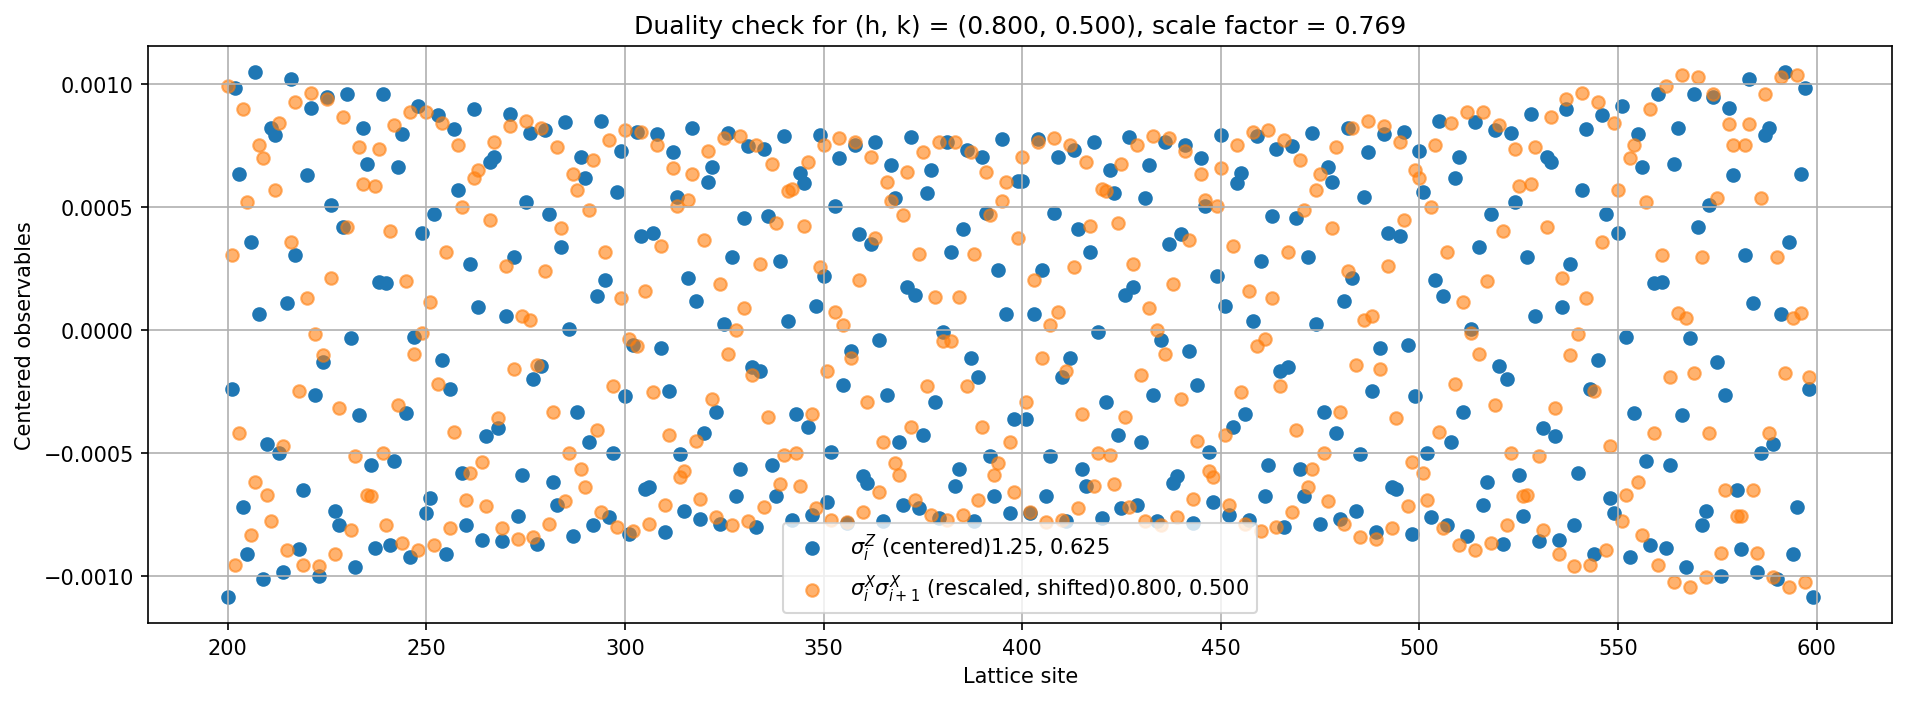

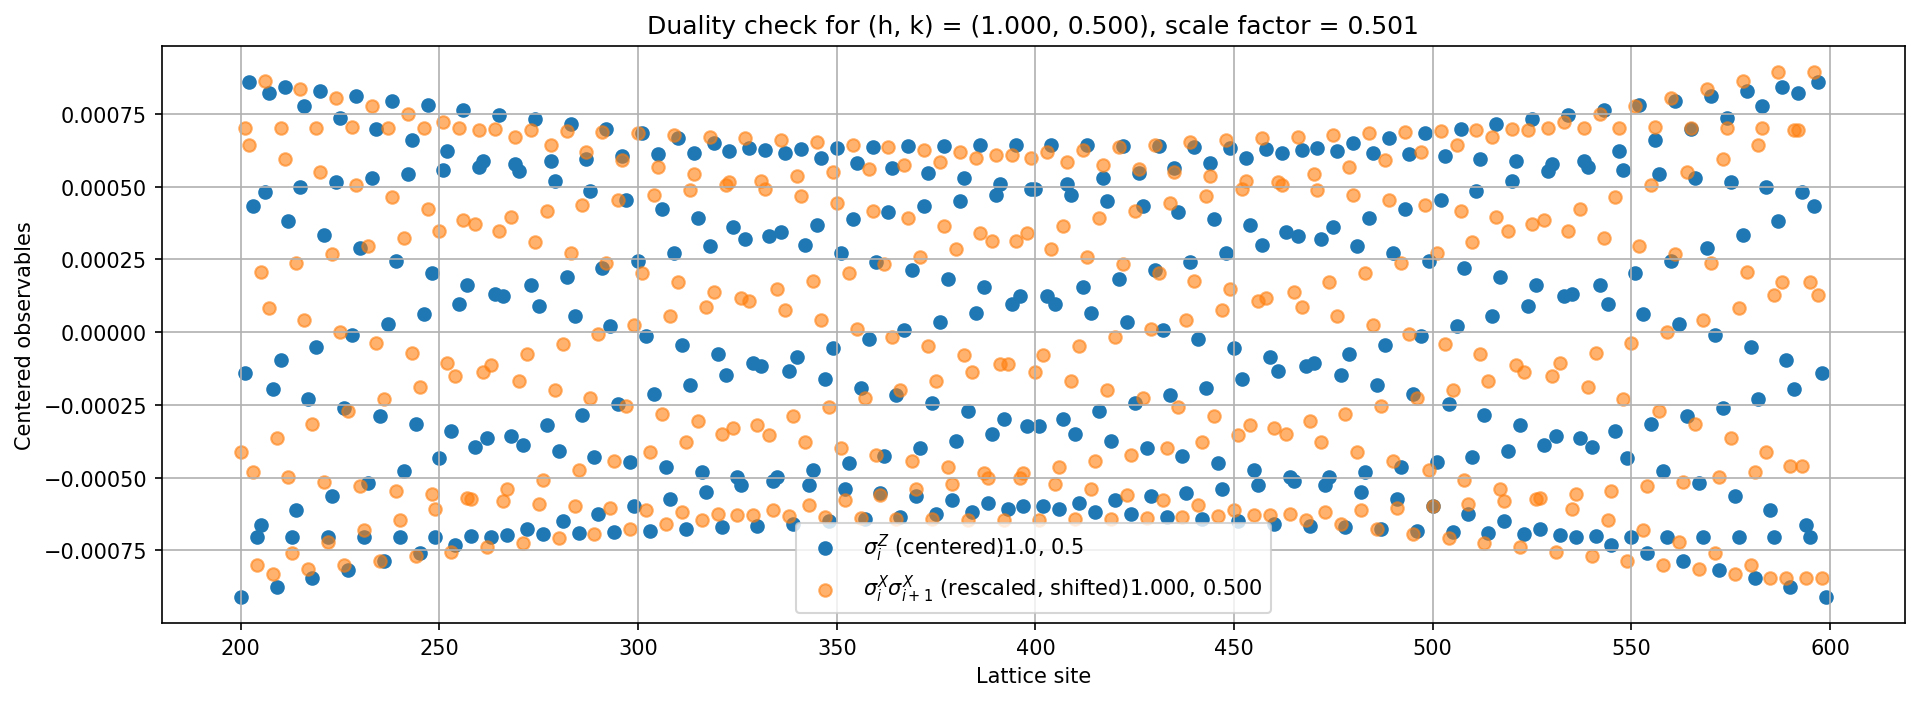

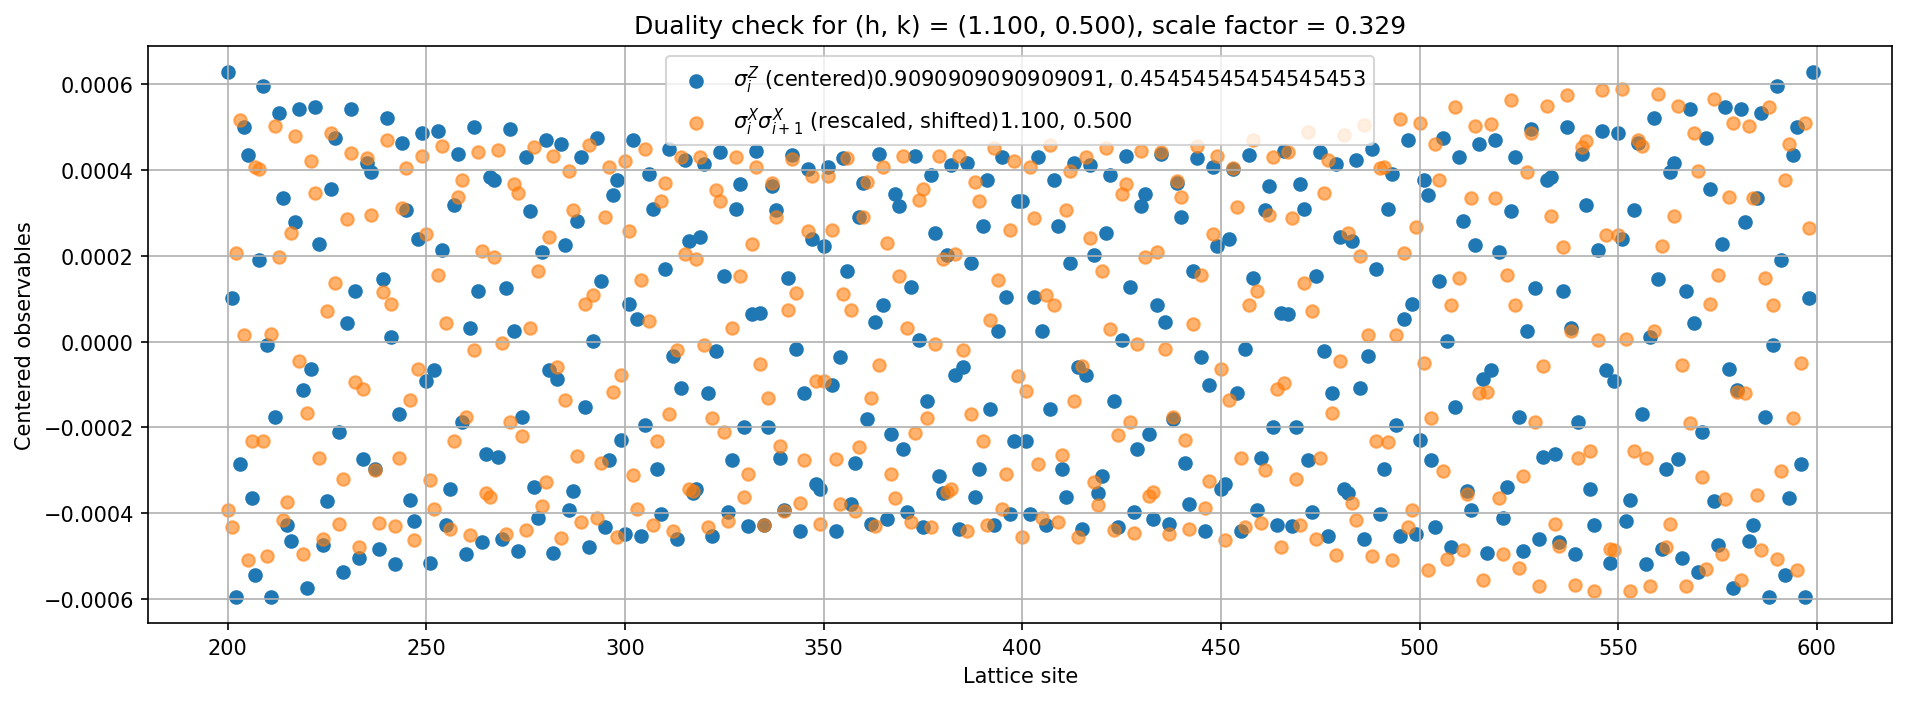

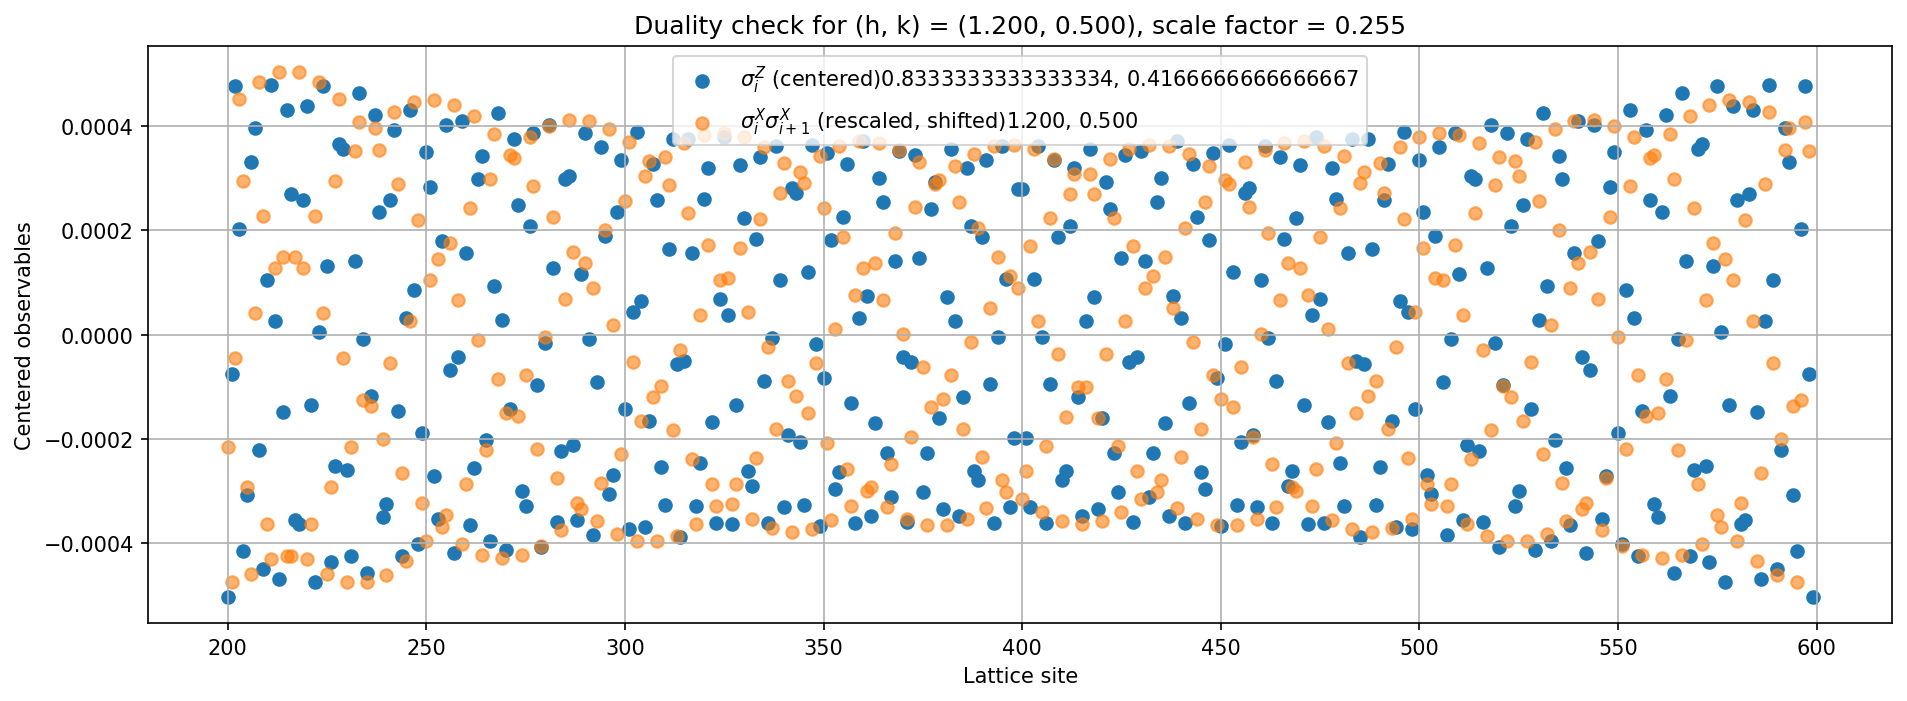

In [37]:
for file in sorted(os.listdir(results)):
    h, k = file.split("_")
    h = h[1:]

    h_dual = 1 / float(h)
    k_dual = float(k) / float(h)
    i_dual = f"h{h_dual:.3f}_{k_dual:.3f}"

    loc = os.path.join(results, file)
    loc_dual = os.path.join(results_dual, i_dual)

    x, Z = np.loadtxt(os.path.join(loc, "Z.txt")).T 
    if not os.path.exists(os.path.join(loc_dual, "XX.txt")):
        continue
    y, XX = np.loadtxt(os.path.join(loc_dual, "XX.txt")).T

    cut = L//4

    Z_centered = Z[cut:-cut]
    XX_rescaled = XX[cut:-cut]
    
    # Remove the mean (background value)
    Z_centered = Z[cut:-cut] - np.mean(Z[cut:-cut])
    XX_centered = XX[cut:-cut] - np.mean(XX[cut:-cut])

    # Rescale XX to match amplitude
    scale_factor = (np.std(Z_centered) / np.std(XX_centered))
    XX_rescaled =  XX_centered * scale_factor

    from scipy.signal import correlate

    # Normalize (important for unbiased shift detection)
    Z_norm = Z_centered / np.linalg.norm(Z_centered)
    XX_norm = XX_rescaled / np.linalg.norm(XX_rescaled)

    # Full cross-correlation
    corr = correlate(XX_norm, Z_norm, mode='full')

    # Compute corresponding lag values
    lags = np.arange(-len(Z_norm) + 1, len(Z_norm))

    # Best integer shift
    phi = lags[np.argmax(corr)]

    XX_shifted = np.roll(XX_rescaled, phi)

    plt.figure(figsize=(15,5))
    plt.scatter(x[cut:-cut], Z_centered, marker="o",
            label=r"$\sigma_i^Z$ (centered)"+f"{h_dual}, {k_dual}")

    plt.scatter(y[cut:-cut], XX_shifted, marker="o", alpha=0.6,
         label=r"$\sigma_i^X\sigma_{i+1}^X$ (rescaled, shifted)"+f"{h}, {k}")   
    plt.grid()
    plt.legend()
    plt.xlabel("Lattice site")
    plt.ylabel("Centered observables")
    plt.title(f"Duality check for (h, k) = ({h}, {k}), scale factor = {scale_factor:.3f}")
    plt.show()


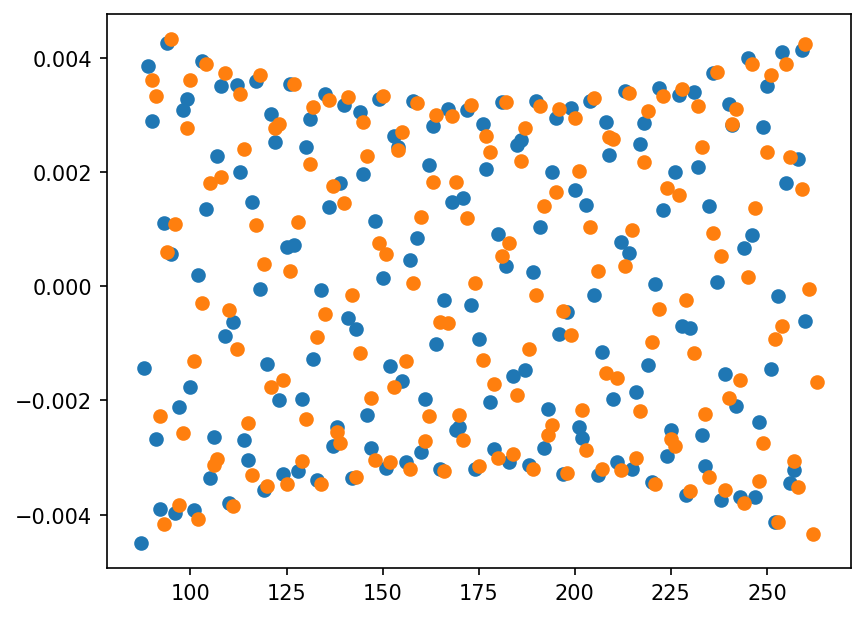

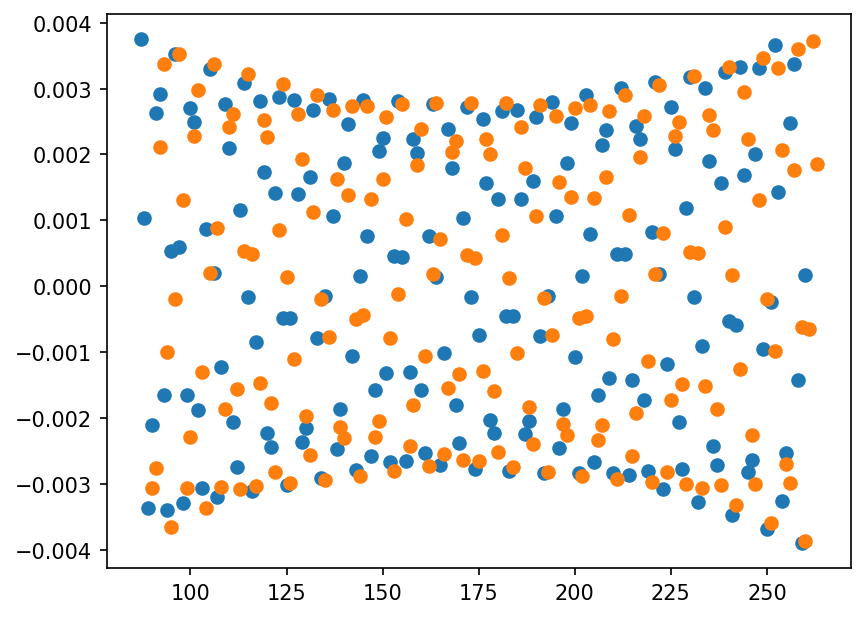

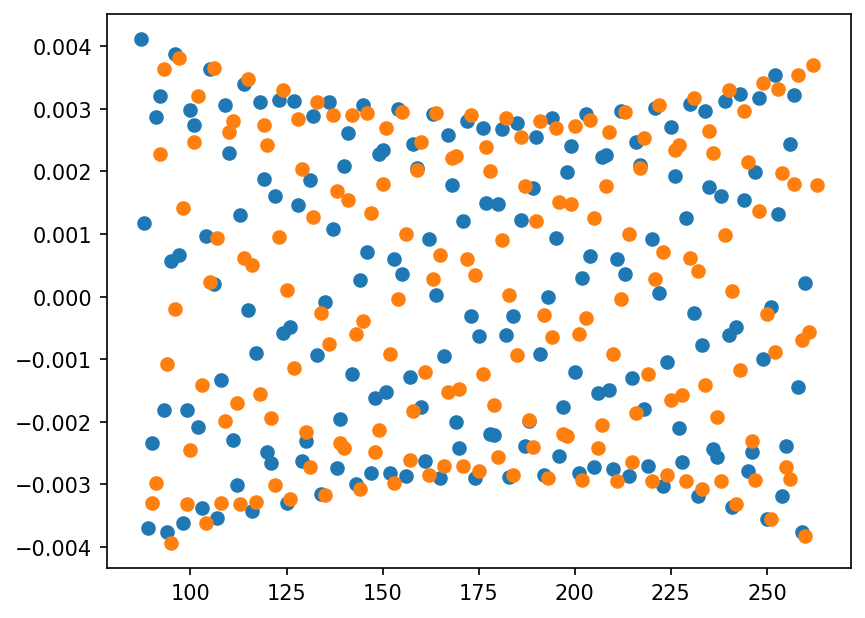

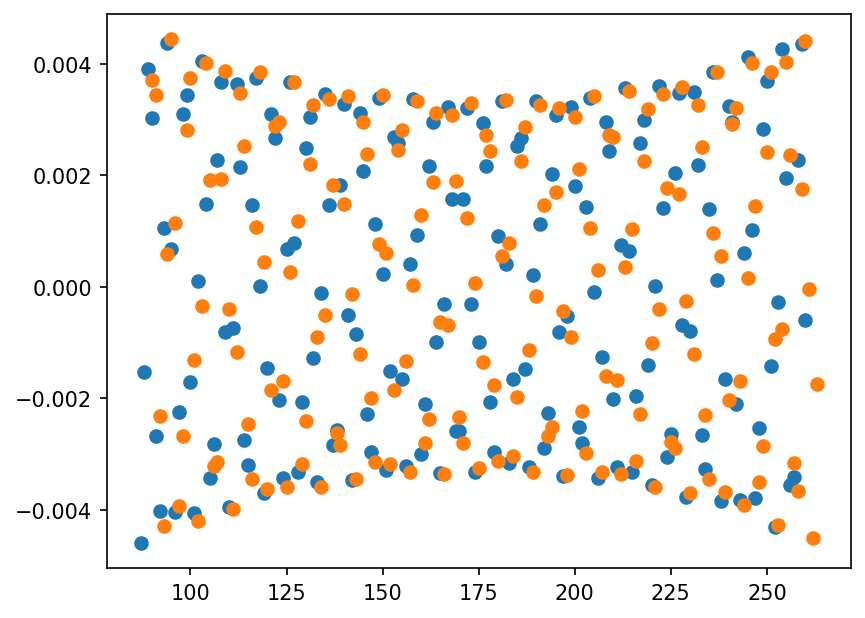

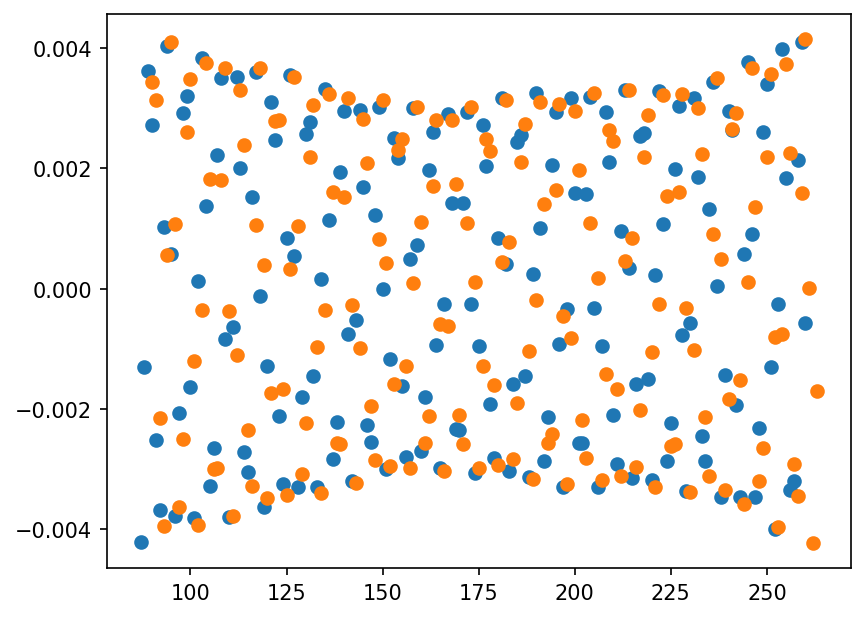

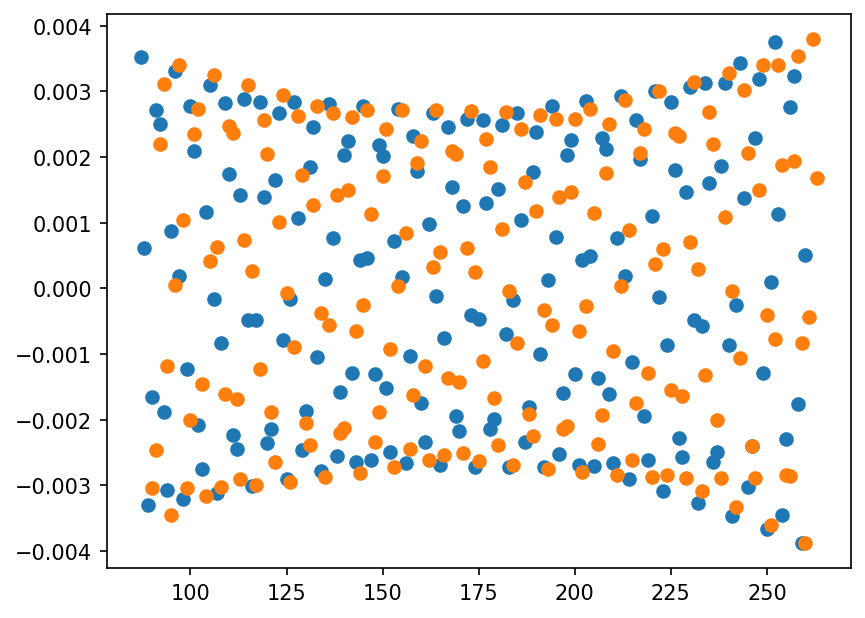

In [15]:
for i in os.listdir(results):
    h, k = i.split("_")
    h = h[1:]
    if float(h) == 0.0:
        continue
    h_dual = 1 / float(h)
    k_dual = float(k) / float(h)
    i_dual = f"h{h_dual:.3f}_{k_dual:.3f}"

    loc = os.path.join(results, i)
    loc_dual = os.path.join(results_dual, i_dual)

    x, XYZ = np.loadtxt(os.path.join(loc, "XYZ.txt")).T
    y, YIX = np.loadtxt(os.path.join(loc, "XIY.txt")).T
    y = L-y
    cut = L // 4
    # Remove the mean (background value)
    YIX_centered = YIX[cut:-cut] - np.mean(YIX[cut:-cut])
    XYZ_centered = XYZ[cut:-cut] - np.mean(XYZ[cut:-cut])

    # # Rescale XX to match amplitude
    scale_factor = (np.std(YIX_centered) / np.std(XYZ_centered))
    XYZ_rescaled =  XYZ_centered * scale_factor

    plt.scatter(x[cut:-cut], XYZ_rescaled)
    plt.scatter(y[cut:-cut], YIX_centered)
    plt.show()

    

(h,k)=(0.850,0.500)  best shift = 3


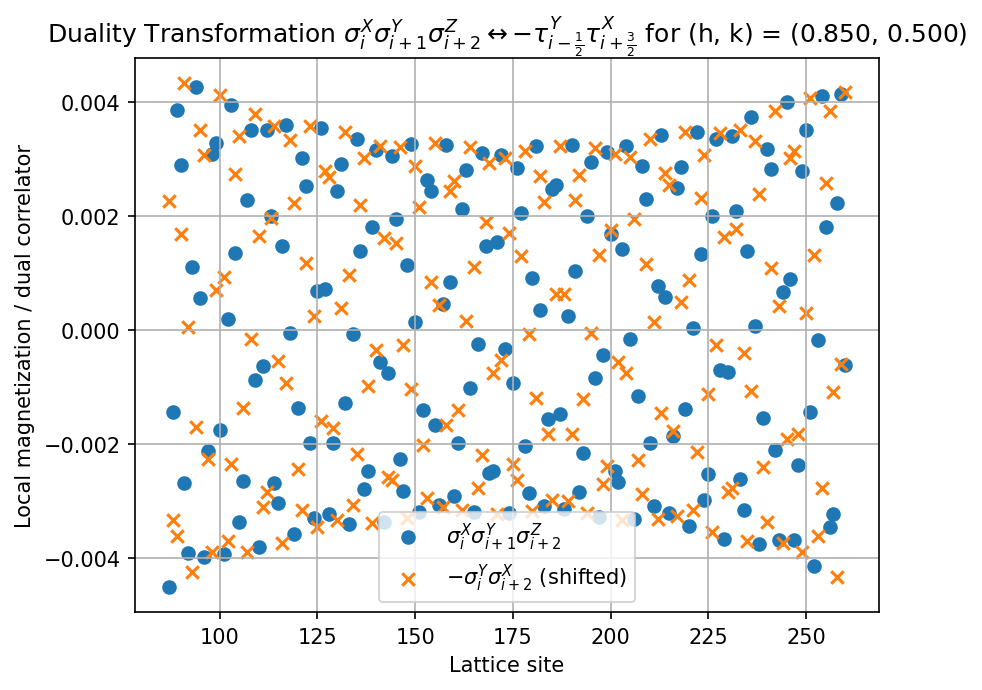

(h,k)=(1.000,0.500)  best shift = 3


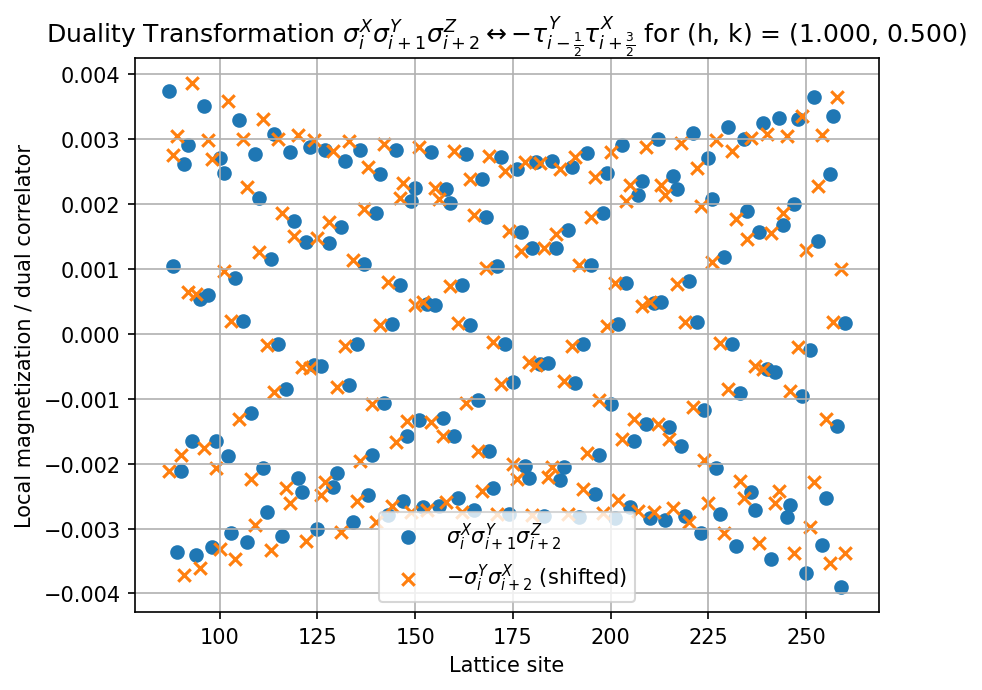

(h,k)=(0.950,0.500)  best shift = 3


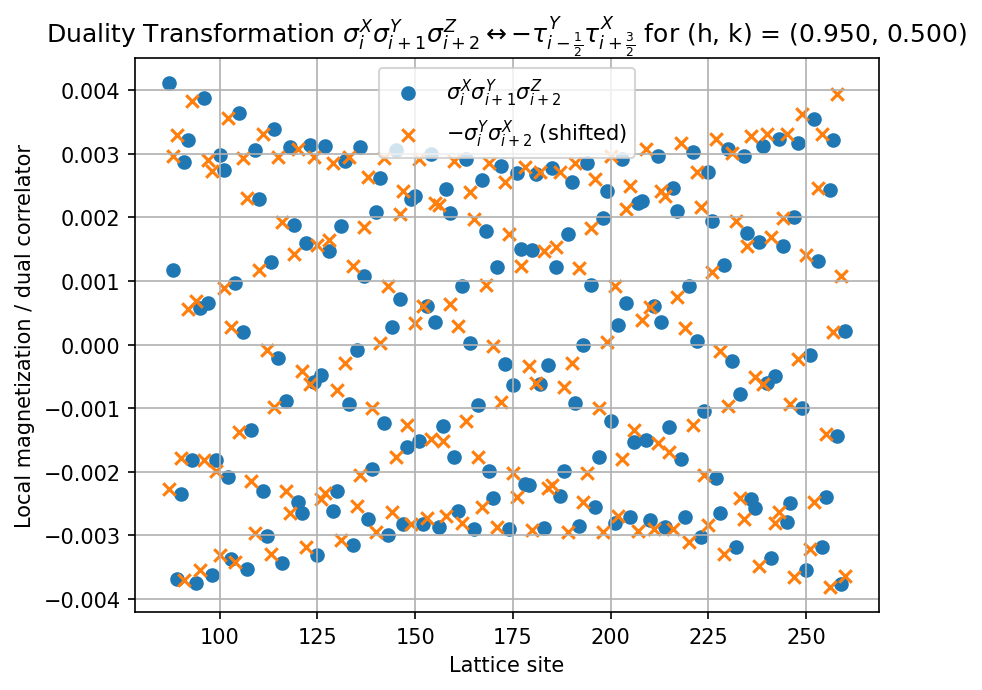

(h,k)=(0.800,0.500)  best shift = 3


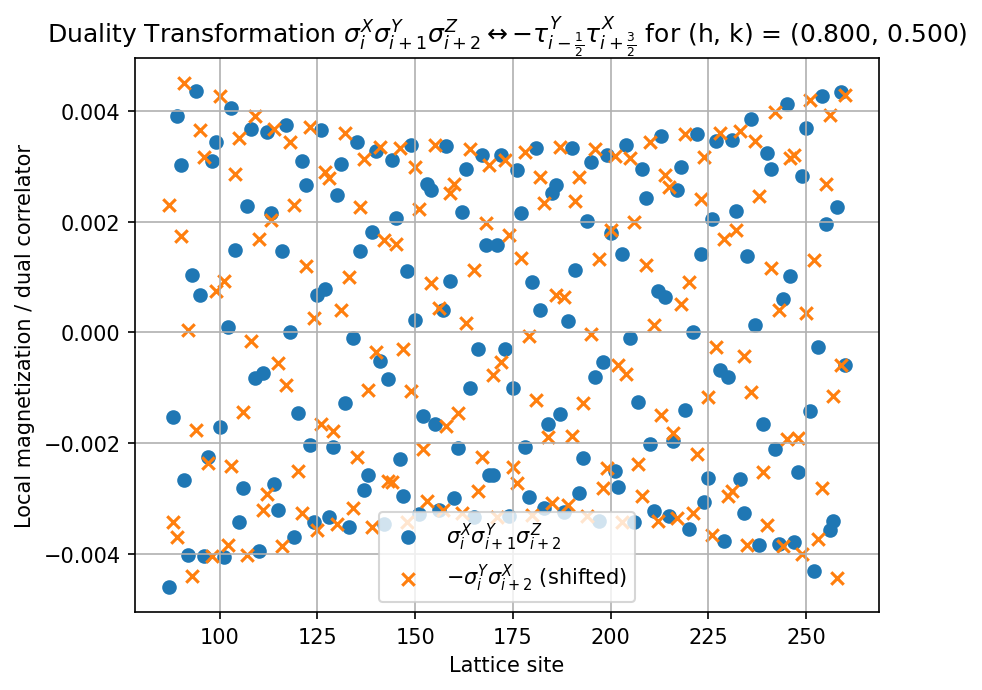

(h,k)=(0.900,0.500)  best shift = 3


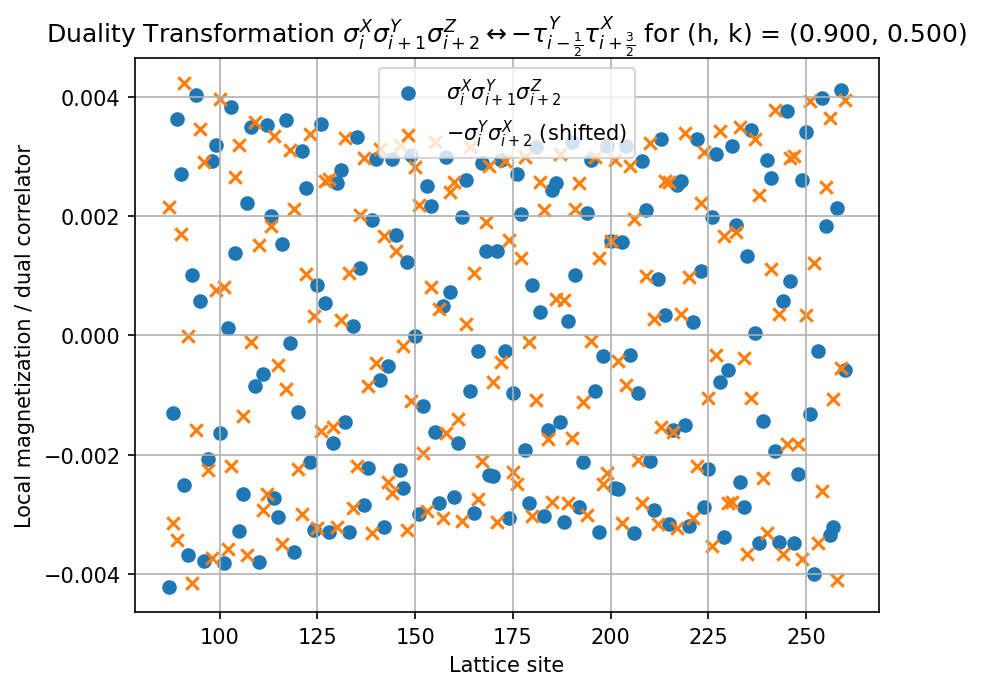

(h,k)=(1.050,0.500)  best shift = 3


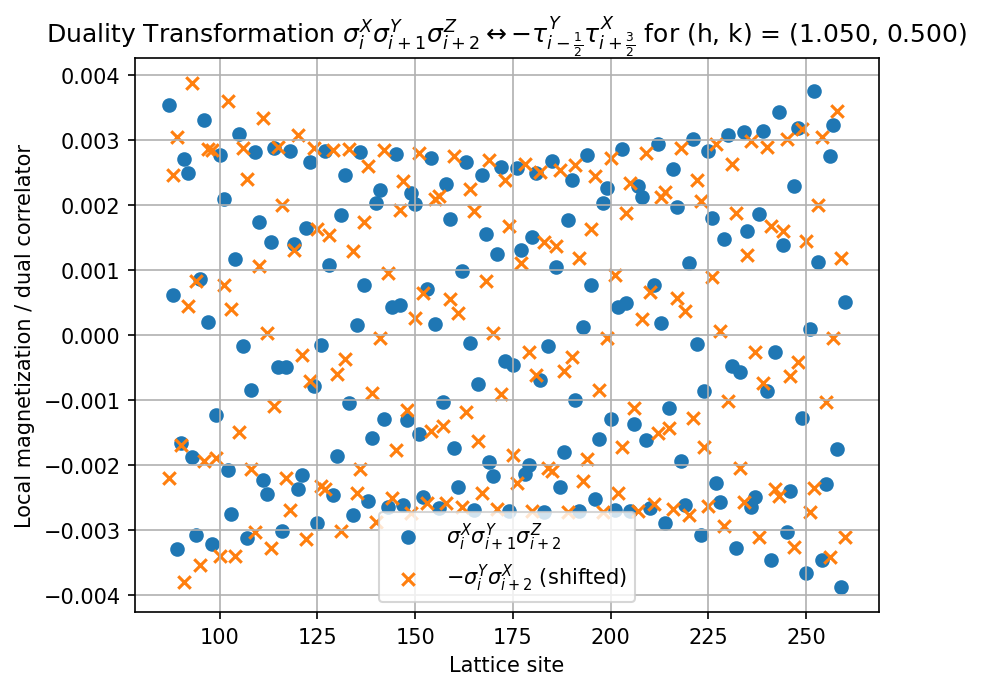

In [16]:
for i in os.listdir(results):
    h, k = i.split("_")
    h = h[1:]
    if float(h) == 0.0:
        continue
    h_dual = 1 / float(h)
    k_dual = float(k) / float(h)
    i_dual = f"h{h_dual:.3f}_{k_dual:.3f}"

    loc = os.path.join(results, i)
    loc_dual = os.path.join(results_dual, i_dual)

    x, XYZ = np.loadtxt(os.path.join(loc, "XYZ.txt")).T
    y, YIX = np.loadtxt(os.path.join(loc, "XIY.txt")).T
    y = L-y

    cut = L // 4
    # Remove the mean (background value)
    YIX_centered = YIX[cut:-cut] - np.mean(YIX[cut:-cut])
    XYZ_centered = XYZ[cut:-cut] - np.mean(XYZ[cut:-cut])

    # # Rescale XX to match amplitude
    scale_factor = (np.std(YIX_centered) / np.std(XYZ_centered))
    XYZ_rescaled =  XYZ_centered * scale_factor

    from scipy.signal import correlate

    # Normalize (important)
    A = XYZ_rescaled / np.linalg.norm(XYZ_rescaled)
    B = (-YIX_centered) / np.linalg.norm(YIX_centered)

    # Full cross-correlation
    corr = correlate(B, A, mode="full")
    lags = np.arange(-len(A) + 1, len(A))

    # Best integer shift
    phi = lags[np.argmax(corr)]

    print(f"(h,k)=({h},{k})  best shift = {phi}")

    YIX_shifted = np.roll(YIX_centered, phi)

    plt.scatter(x[cut:-cut], XYZ_rescaled,
            marker="o",
            label=r"$\sigma_i^X\sigma_{i+1}^Y\sigma_{i+2}^Z$")

    plt.scatter(x[cut:-cut], -YIX_shifted,
            marker="x",
            label=r"$-\sigma_{i}^Y\sigma_{i+2}^X$ (shifted)")
    plt.grid()
    plt.legend()
    plt.xlabel("Lattice site")
    plt.ylabel("Local magnetization / dual correlator")
    plt.title(r"Duality Transformation $\sigma_i^X\sigma_{i+1}^Y\sigma_{i+2}^Z \leftrightarrow $" \
    r"$-\tau_{i-\frac{1}{2}}^Y\tau_{i+\frac{3}{2}}^X$"+f" for (h, k) = ({h}, {k})")
    plt.show()
    

## Fitting q and K

Now that we know that we have a LL phase, we start looking for a fit of q and K.

According to bCFT, we expect Friedel Oscillations of a finite size system to follow:
$$\langle \sigma_i \rangle \propto \frac{\cos{(qi + \phi)}}{\left[(N/\pi) \cos{(\pi i/N)}\right]^K}$$

In order to get a good guess for all our parameters, we need to fit in phases - first we fit the envelope, then the oscillations. If we have the full function below:

$$\langle \sigma_i \rangle = A\frac{\cos{(qi + \phi)}}{\left[(N/\pi) \cos{(\pi i/N)}\right]^K} + B$$

We start by fitting for K, which controls the amplitudes via 

  0%|          | 0/5 [00:00<?, ?it/s]

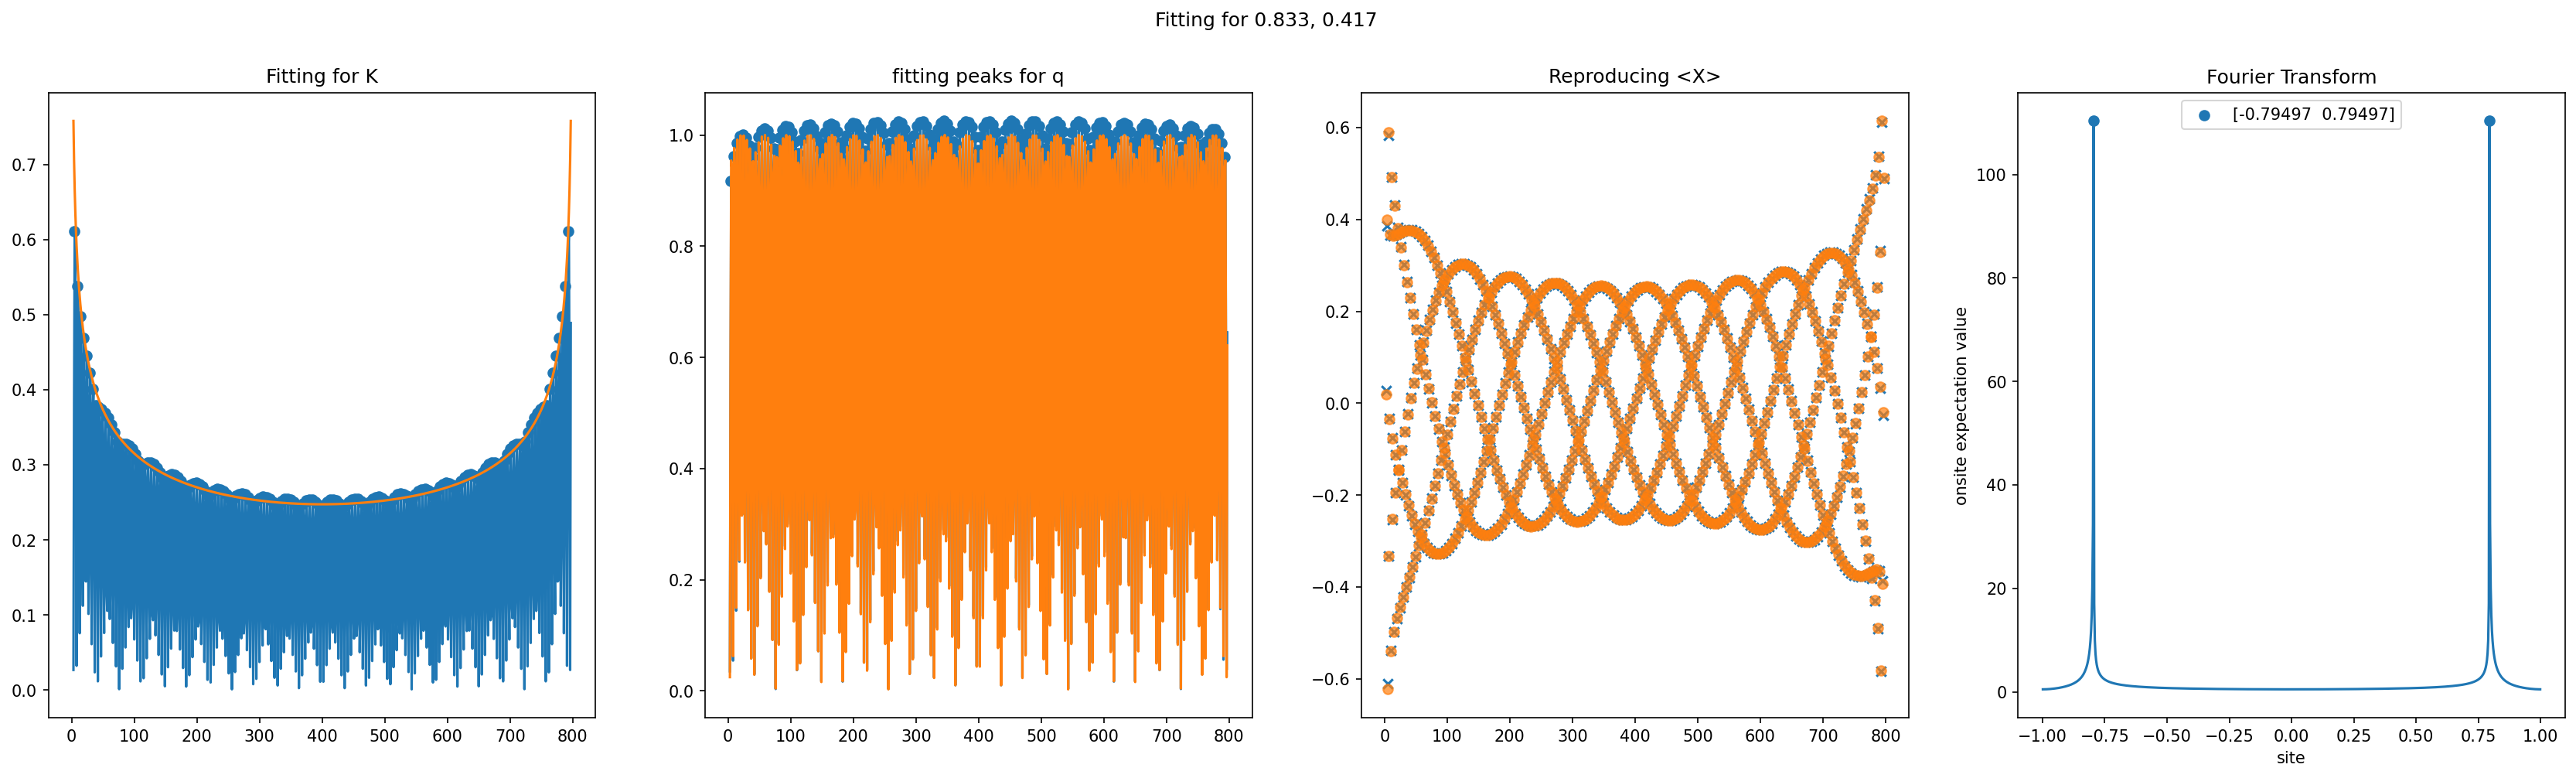

 20%|██        | 1/5 [00:00<00:03,  1.15it/s]

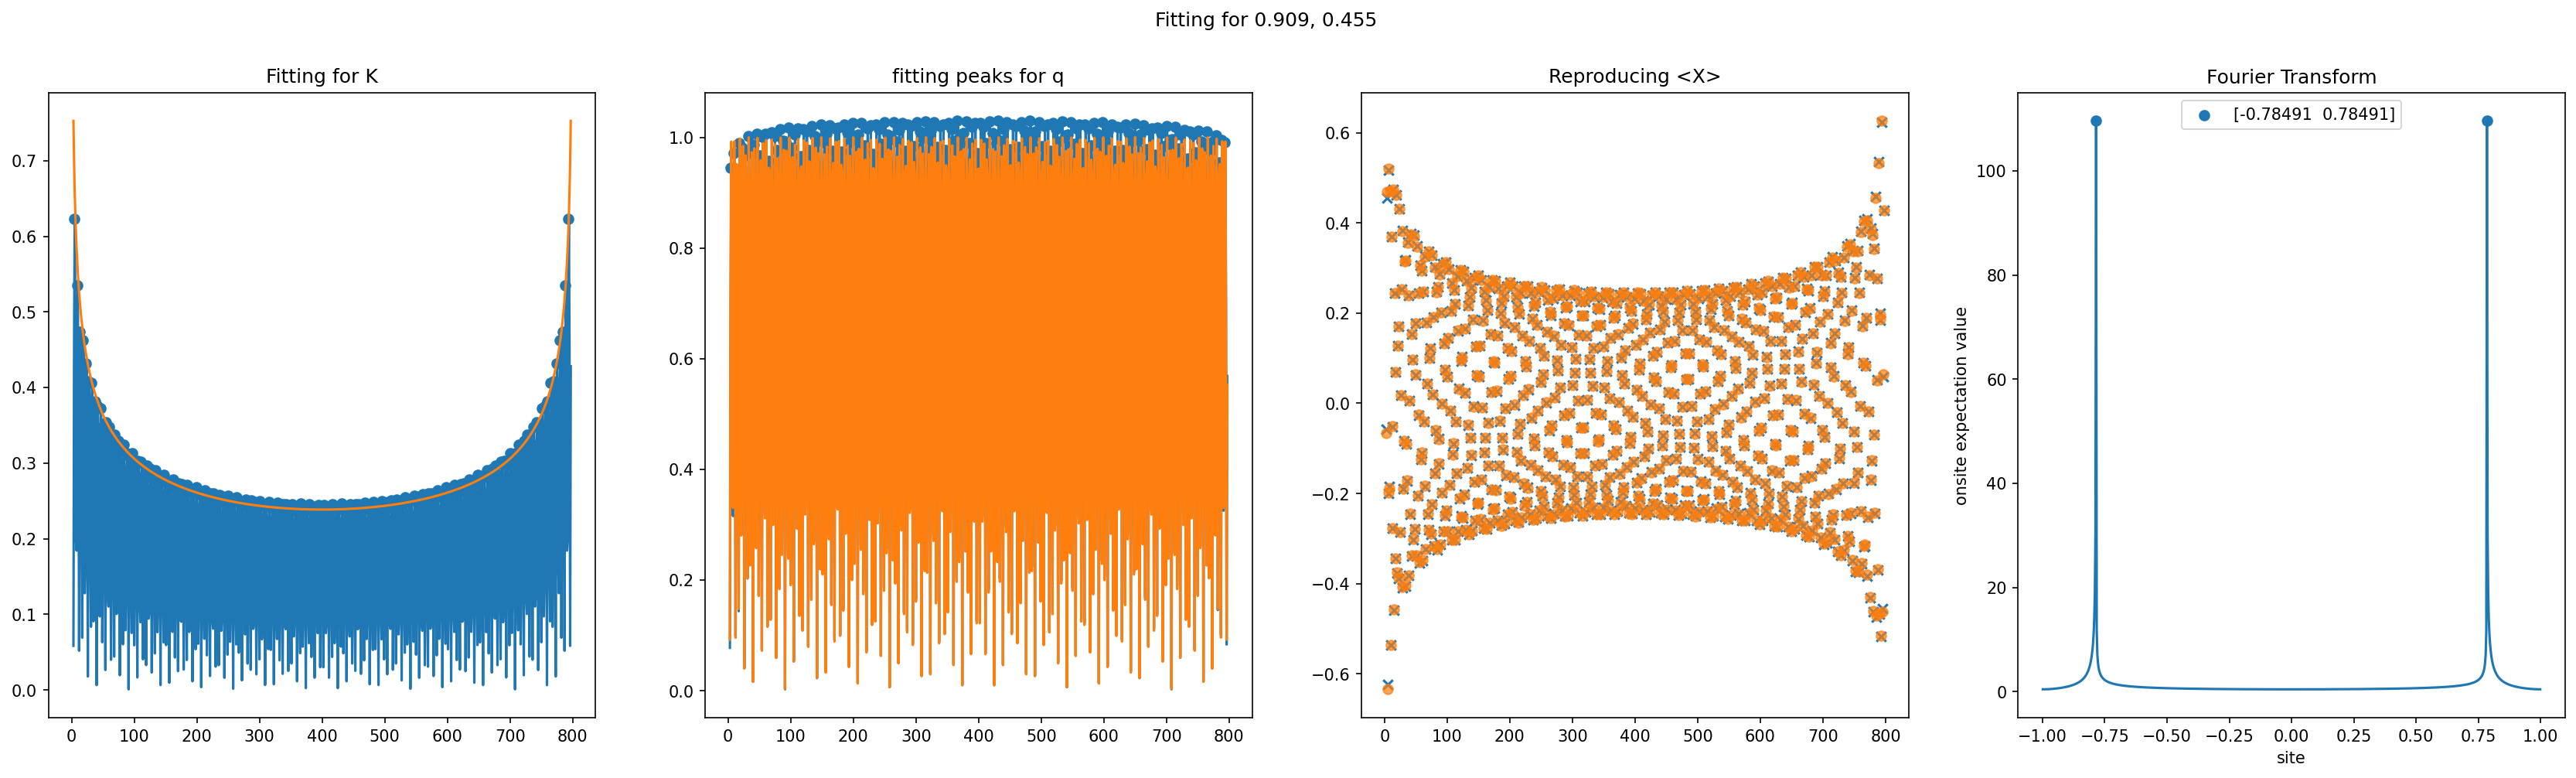

 40%|████      | 2/5 [00:01<00:02,  1.13it/s]

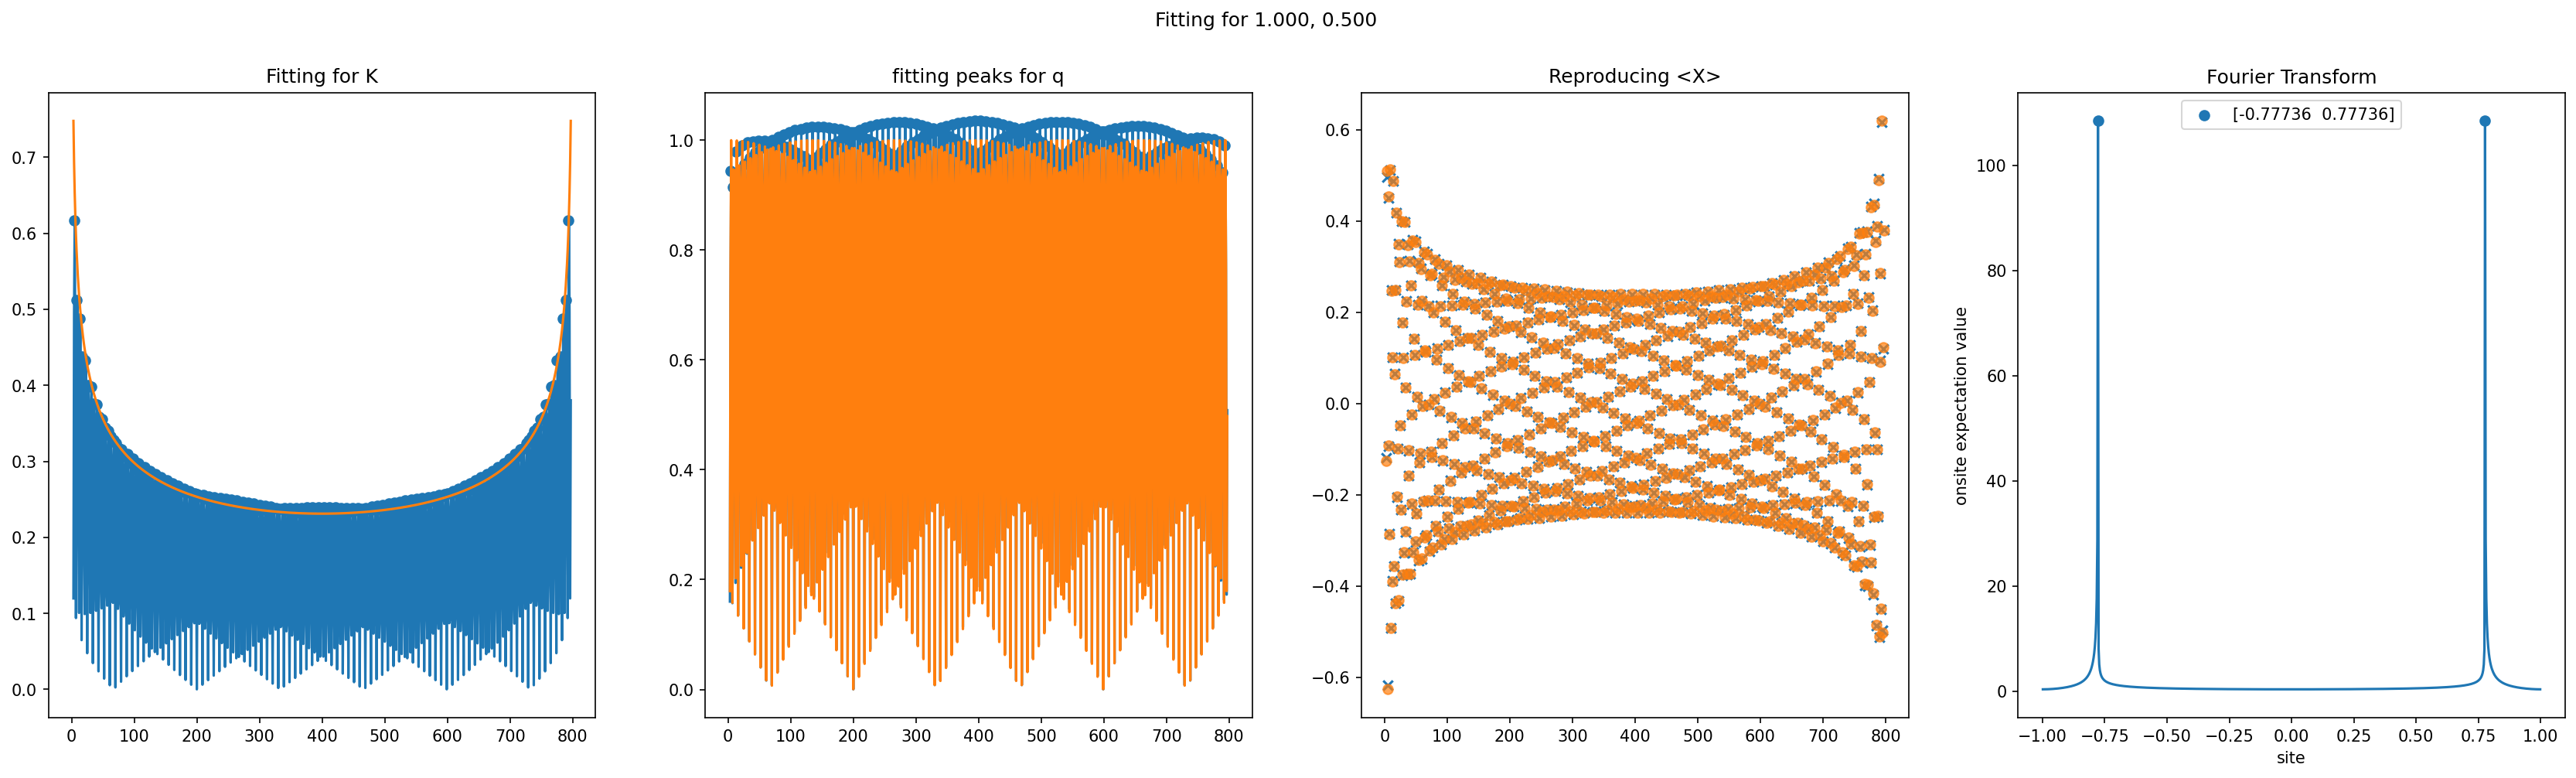

 60%|██████    | 3/5 [00:02<00:01,  1.06it/s]

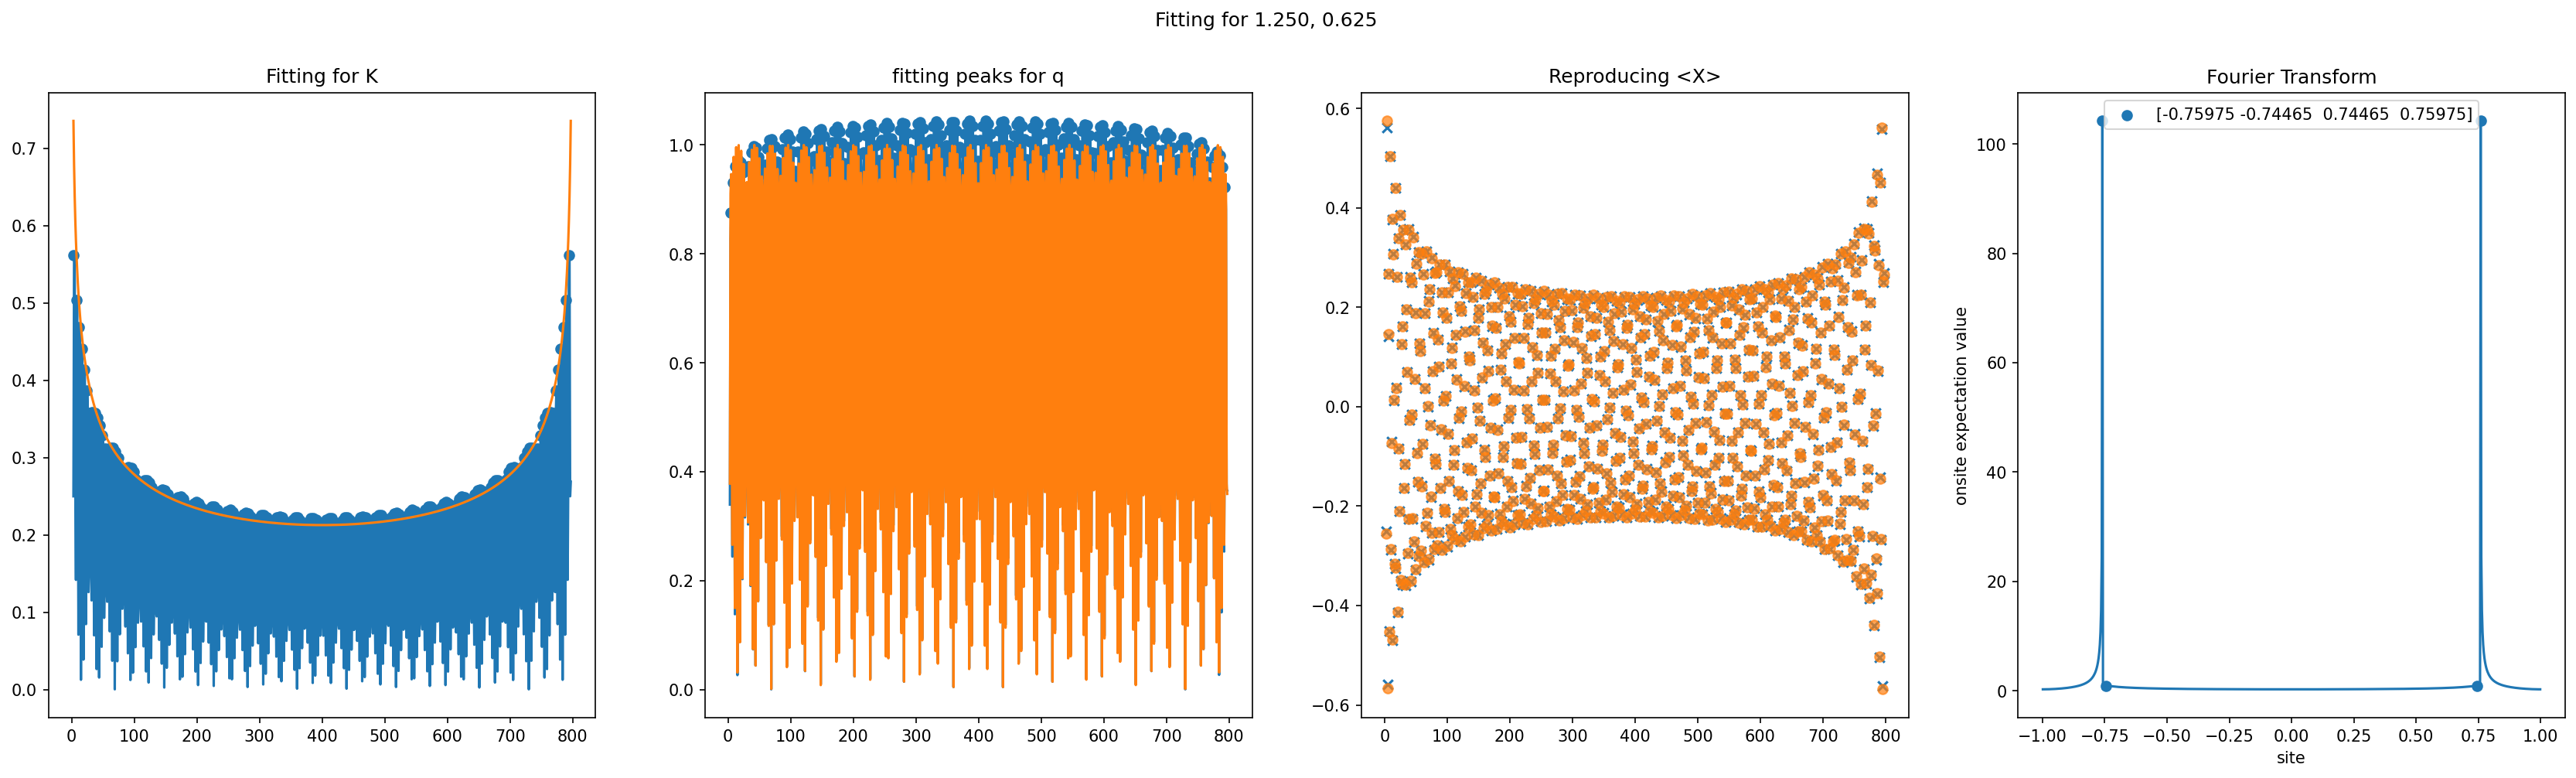

 80%|████████  | 4/5 [00:03<00:00,  1.06it/s]

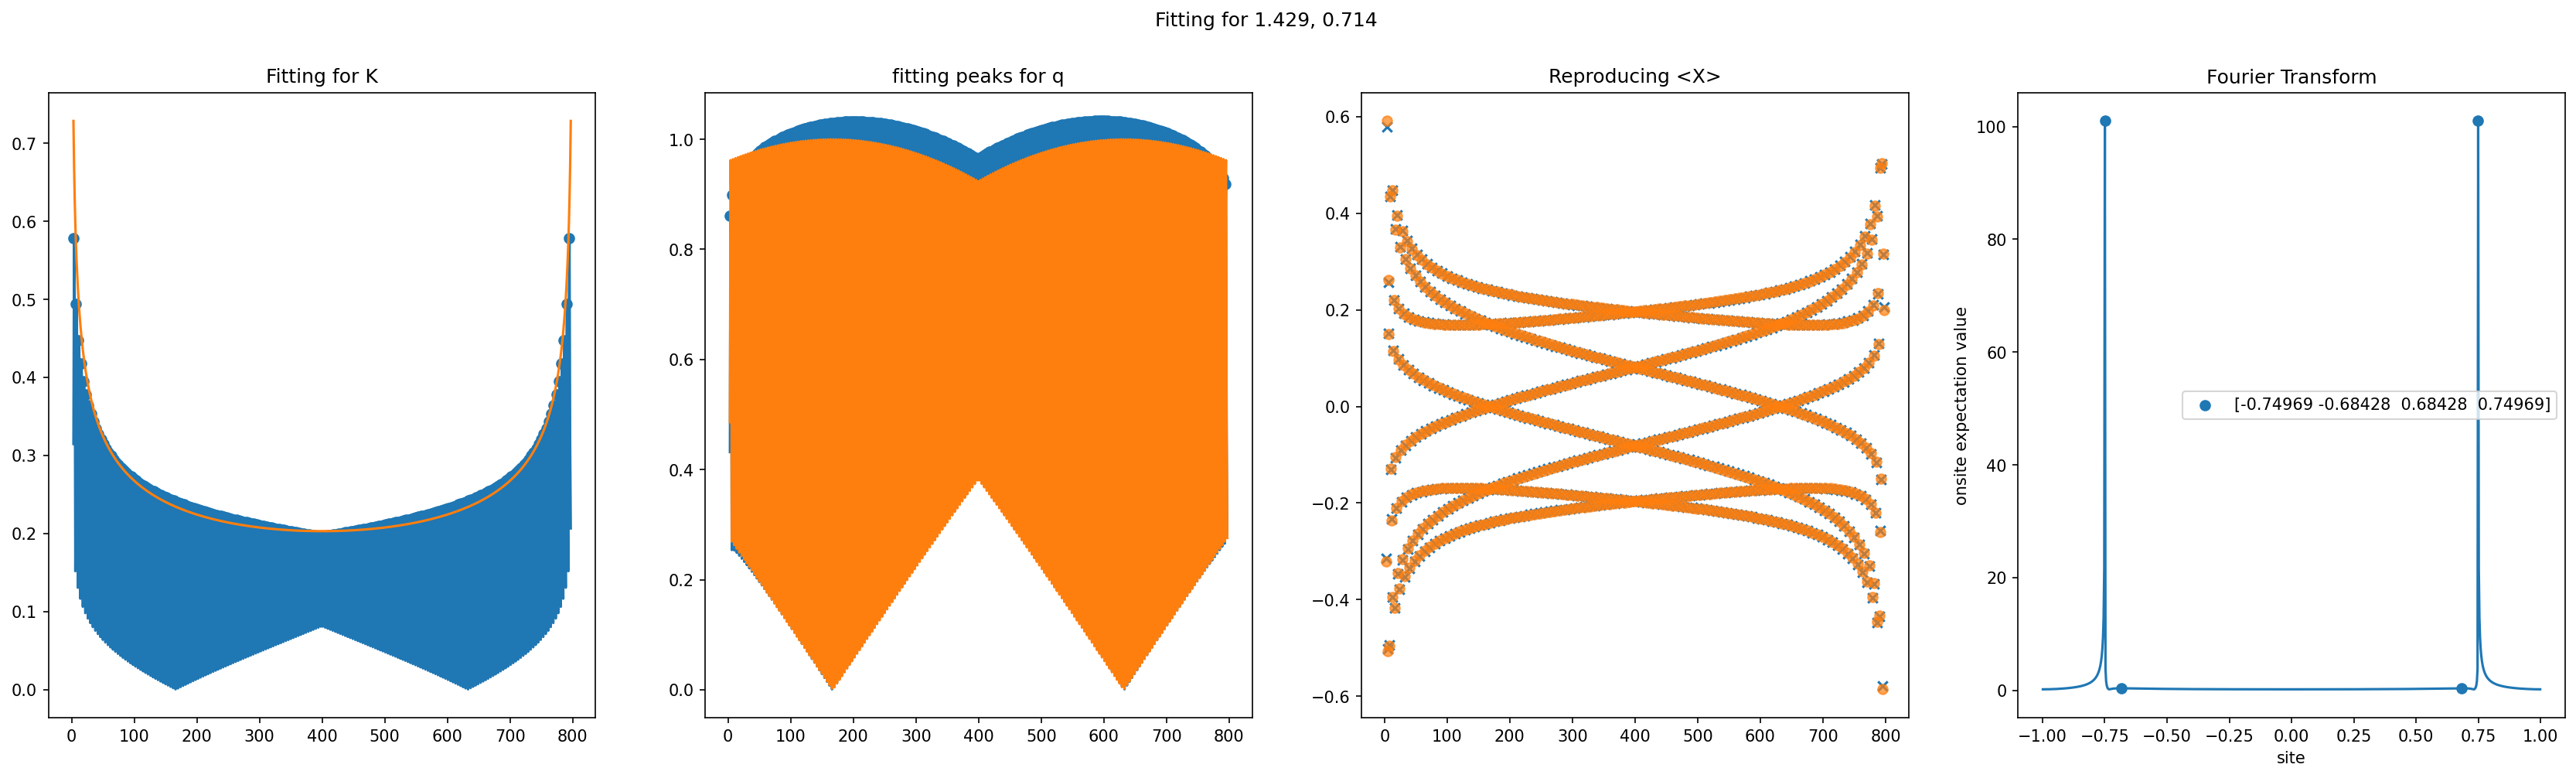

100%|██████████| 5/5 [00:04<00:00,  1.08it/s]


In [39]:
# onsite expectation values
plotting=True

params = []
K = []
q = []
q_fft = []
phiz = []

for i in tqdm(sorted(os.listdir(results_dual))):
    # extract magnetization values
    loc = os.path.join(results, i)
    loc_dual = os.path.join(results+"_dual", i)
    h, k = i.split("_")
    h = h[1:] 
    # for h < 1
    x, X = np.loadtxt(os.path.join(loc_dual, "X.txt")).T

    # cut the ends
    cut = 2
    valid = (x > cut) & (x < (L - cut))
    x = x[valid]
    X = X[valid]

    ##### finding K guess ######
    peaks = scipy.signal.find_peaks(np.abs(X))

    if np.abs(X).size==0:
        continue
    X_peaks = [X[i] for i in peaks[0]]

    # fit those peaks to fred_two
    def fred_two(x, K):
        numerator = 1
        denominator = ((L/np.pi) * np.sin(np.pi * x / L))**K
        return (numerator/denominator)
    
    if len(X_peaks) == 0:
        continue

    popt, pcov = curve_fit(fred_two, peaks[0], np.abs(X_peaks))


    ##### Fitting q #####

    # sanitize the results, and look for q
    X_sanitized = X * ((L/np.pi) * np.sin(np.pi * x / L))**popt[0]

    peaks_length = scipy.signal.find_peaks(np.abs(X_sanitized))
    lengths = peaks_length[0]
    wavelengths = [lengths[i+1] - lengths[i] for i in range(len(lengths)-1)] 
    test_q = 0 if len(wavelengths)==0 else np.pi / np.mean(wavelengths)

    def fred_one(x,A,q,phi):
        return A * np.abs(np.cos(q*x + phi))

    popt1, pcov1 = curve_fit(fred_one, x, np.abs(X_sanitized),
                            bounds=([-1, 0, 0],[1, 2*np.pi, L]),
                            p0=[1, np.pi-test_q, test_q/np.pi])
    
    # -- Check for A -- #
    def friedel_core(x, q, phi, L, K):
        return np.cos(q * x + phi) / (((L/np.pi) * np.sin(np.pi * x / L))**K)

    model_core = friedel_core(x, popt1[1], popt1[2], L, popt[0])

    res_plus  = np.sum(( X - (+1) * model_core )**2)
    res_minus = np.sum(( X - (-1) * model_core )**2)

    A = +1 if res_plus < res_minus else -1

    ##### Reproducing X #####
    def friedel_oscillations(x, A, B, phi, L, q, K):
        numerator = np.cos(q * x + phi)
        denominator = ((L/np.pi ) * np.sin(np.pi * x / L))**K
        return A * (numerator/denominator) + B
    
    popt_final, pcov_final = curve_fit(friedel_oscillations, x, X, p0=[
        A, 0, popt1[2], L, popt1[1], popt[0]
    ])

    # Check Fourier Transform

    X_fft = np.fft.fftshift(np.fft.fft(X))
    freqs = np.fft.fftshift(np.fft.fftfreq(len(X_fft), d=1)) * 2

    leading_freqs = scipy.signal.find_peaks(np.abs(X_fft))
    leading_freqs = leading_freqs[0]  
    leader = np.pi if len(leading_freqs) < 2 else leading_freqs[-1]  

    # save and move on
    params.append([float(h), float(k)])
    K.append(popt_final[5])
    q.append(popt_final[4])
    phiz.append(popt_final[2])
    q_fft.append(freqs[leader])
    
    #### - Plotting - #####
    if plotting:
        fig, ax = plt.subplots(1, 4, figsize=(28, 7))
        fig.suptitle(f"Fitting for {h}, {k}")

        ax[0].plot(x, np.abs(X), label=f"X, {h}, {k}")
        ax[0].scatter(peaks[0]+cut, np.abs(X_peaks), label="peaks")
        ax[0].plot(x, (fred_two(x, *popt)), label=f"fit, K={popt[0]}")
        ax[0].set_title("Fitting for K")

        ax[1].set_title("fitting peaks for q")
        ax[1].plot(x, np.abs(X_sanitized), label="Sanitized X")
        ax[1].scatter(peaks_length[0]+cut, np.abs(X_sanitized)[peaks_length[0]], label="peaks")
        ax[1].plot(x, fred_one(x, *popt1), label=f"fit, q={q}")

        ax[2].set_title("Reproducing <X>")
        ax[2].scatter(x, X, marker="x")
        ax[2].scatter(x, friedel_oscillations(x, *popt_final), alpha=0.7, label=f"K={popt[0]}, q={popt1[1]/np.pi}")

        ax[3].set_title("Fourier Transform")
        ax[3].plot(freqs, np.abs(X_fft))
        ax[3].scatter(freqs[leading_freqs], np.abs(X_fft[leading_freqs]), label=f"{freqs[leading_freqs]}")

        plt.xlabel("site")
        plt.ylabel("onsite expectation value")
        plt.legend()
        plt.show()


100%|██████████| 5/5 [00:00<00:00, 85.71it/s]


Text(0.5, 0, 'h')

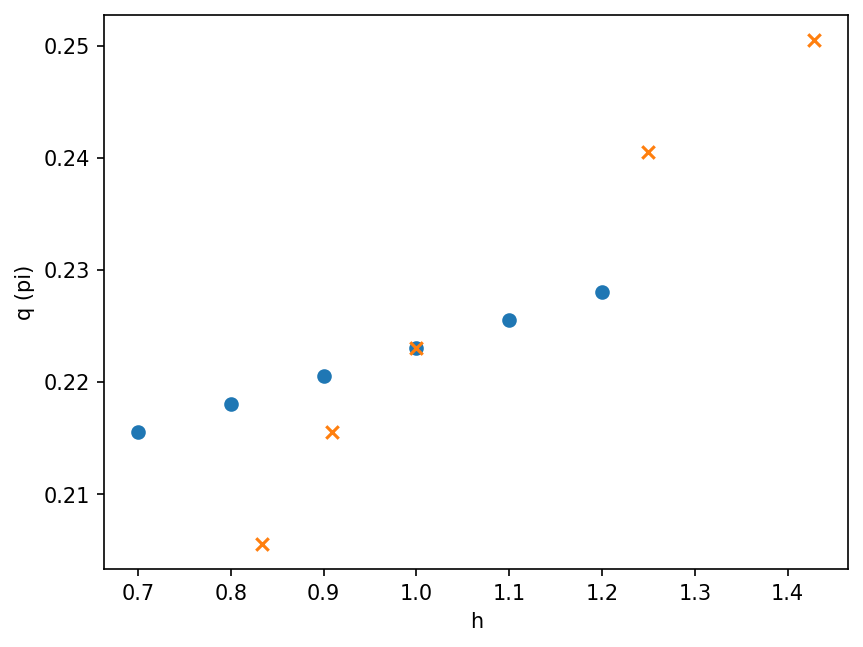

In [38]:
def find_q_K(results):
    # onsite expectation values
    plotting=False

    params = []
    K = []
    q = []
    q_fft = []
    phiz = []

    for i in tqdm(sorted(os.listdir(results))):
        # extract magnetization values
        loc = os.path.join(results, i)
        h, k = i.split("_")
        h = h[1:] 
        # for h < 1
        x, X = np.loadtxt(os.path.join(loc, "X.txt")).T

        # cut the ends
        cut = 2
        valid = (x > cut) & (x < (L - cut))
        x = x[valid]
        X = X[valid]

        ##### finding K guess ######
        peaks = scipy.signal.find_peaks(np.abs(X))

        if np.abs(X).size==0:
            continue
        X_peaks = [X[i] for i in peaks[0]]

        # fit those peaks to fred_two
        def fred_two(x, K):
            numerator = 1
            denominator = ((L/np.pi) * np.sin(np.pi * x / L))**K
            return (numerator/denominator)
        
        if len(X_peaks) == 0:
            continue

        popt, pcov = curve_fit(fred_two, peaks[0], np.abs(X_peaks))


        ##### Fitting q #####

        # sanitize the results, and look for q
        X_sanitized = X * ((L/np.pi) * np.sin(np.pi * x / L))**popt[0]

        peaks_length = scipy.signal.find_peaks(np.abs(X_sanitized))
        lengths = peaks_length[0]
        wavelengths = [lengths[i+1] - lengths[i] for i in range(len(lengths)-1)] 
        test_q = 0 if len(wavelengths)==0 else np.pi / np.mean(wavelengths)

        def fred_one(x,A,q,phi):
            return A * np.abs(np.cos(q*x + phi))

        popt1, pcov1 = curve_fit(fred_one, x, np.abs(X_sanitized),
                                bounds=([-1, 0, 0],[1, 2*np.pi, L]),
                                p0=[1, np.pi-test_q, test_q/np.pi])
        
        # -- Check for A -- #
        def friedel_core(x, q, phi, L, K):
            return np.cos(q * x + phi) / (((L/np.pi) * np.sin(np.pi * x / L))**K)

        model_core = friedel_core(x, popt1[1], popt1[2], L, popt[0])

        res_plus  = np.sum(( X - (+1) * model_core )**2)
        res_minus = np.sum(( X - (-1) * model_core )**2)

        A = +1 if res_plus < res_minus else -1

        ##### Reproducing X #####
        def friedel_oscillations(x, A, B, phi, L, q, K):
            numerator = np.cos(q * x + phi)
            denominator = ((L/np.pi ) * np.sin(np.pi * x / L))**K
            return A * (numerator/denominator) + B
        
        popt_final, pcov_final = curve_fit(friedel_oscillations, x, X, p0=[
            A, 0, popt1[2], L, popt1[1], popt[0]
        ])

        # Check Fourier Transform

        X_fft = np.fft.fftshift(np.fft.fft(X))
        freqs = np.fft.fftshift(np.fft.fftfreq(len(X_fft), d=1)) * 2

        leading_freqs = scipy.signal.find_peaks(np.abs(X_fft))
        leading_freqs = leading_freqs[0]  
        leader = np.pi if len(leading_freqs) < 2 else leading_freqs[-1]  

        # save and move on
        params.append([float(h), float(k)])
        K.append(popt_final[5])
        q.append(popt_final[4])
        phiz.append(popt_final[2])
        q_fft.append(freqs[leader])
        
        #### - Plotting - #####
        if plotting:
            fig, ax = plt.subplots(1, 4, figsize=(28, 7))
            fig.suptitle(f"Fitting for {h}, {k}")

            ax[0].plot(x, np.abs(X), label=f"X, {h}, {k}")
            ax[0].scatter(peaks[0]+cut, np.abs(X_peaks), label="peaks")
            ax[0].plot(x, (fred_two(x, *popt)), label=f"fit, K={popt[0]}")
            ax[0].set_title("Fitting for K")

            ax[1].set_title("fitting peaks for q")
            ax[1].plot(x, np.abs(X_sanitized), label="Sanitized X")
            ax[1].scatter(peaks_length[0]+cut, np.abs(X_sanitized)[peaks_length[0]], label="peaks")
            ax[1].plot(x, fred_one(x, *popt1), label=f"fit, q={q}")

            ax[2].set_title("Reproducing <X>")
            ax[2].scatter(x, X, marker="x")
            ax[2].scatter(x, friedel_oscillations(x, *popt_final), alpha=0.7, label=f"K={popt[0]}, q={popt1[1]/np.pi}")

            ax[3].set_title("Fourier Transform")
            ax[3].plot(freqs, np.abs(X_fft))
            ax[3].scatter(freqs[leading_freqs], np.abs(X_fft[leading_freqs]), label=f"{freqs[leading_freqs]}")

            plt.xlabel("site")
            plt.ylabel("onsite expectation value")
            plt.legend()
            plt.show()
    return np.array(K), np.array(q), np.array(q_fft), np.array(params)

K, q, q_fft, params = find_q_K(results)
Kdual, qdual, q_fftdual, params_dual = find_q_K(results_dual)

plt.scatter(params.T[0], 1-q/np.pi, label="real")
plt.scatter(params_dual.T[0], 1-qdual/np.pi, marker="x", label="momentum")
# plt.ylim(0, 1)
plt.ylabel("q (pi)")
plt.xlabel("h")

[np.float64(0.7949685534591194), np.float64(0.7849056603773584), np.float64(0.7773584905660377), np.float64(0.7597484276729559), np.float64(0.7496855345911949)]
5 5


Text(0.5, 1.0, 'Wavevector q')

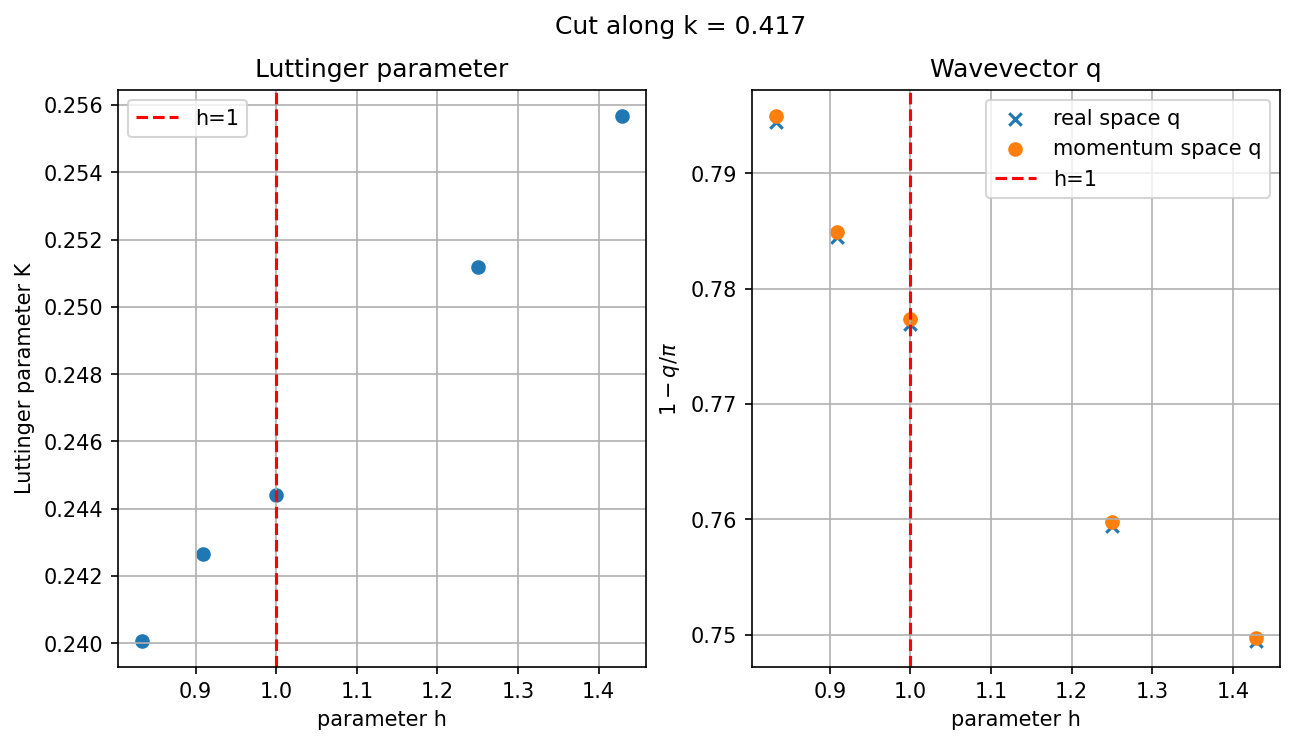

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
q_fft_copy = q_fft
# for i in range(10):
#     q_fft_copy[i] = 1

h, k = np.array(params).T
red_line=1

fig.suptitle(f"Cut along k = {k[0]}") 
ax[0].scatter(h, K)
ax[0].axvline(red_line, ls = "--", c='red', label = f"h={red_line}")
ax[0].grid()
ax[0].legend()
ax[0].set_xlabel("parameter h")
ax[0].set_ylabel("Luttinger parameter K")
ax[0].set_title(f"Luttinger parameter")

ax[1].scatter(h, np.array(q)/np.pi, marker="x",label="real space q")
ax[1].scatter(h, np.array(q_fft), label="momentum space q")
ax[1].axvline(red_line, ls = "--", c='red',label = f"h={red_line}")
ax[1].grid()
ax[1].legend()
ax[1].set_xlabel("parameter h")
ax[1].set_ylabel(r"$1 - q / \pi$")
ax[1].set_title(f"Wavevector q")

## Correlation Functions

  0%|          | 0/6 [00:00<?, ?it/s]

43
43


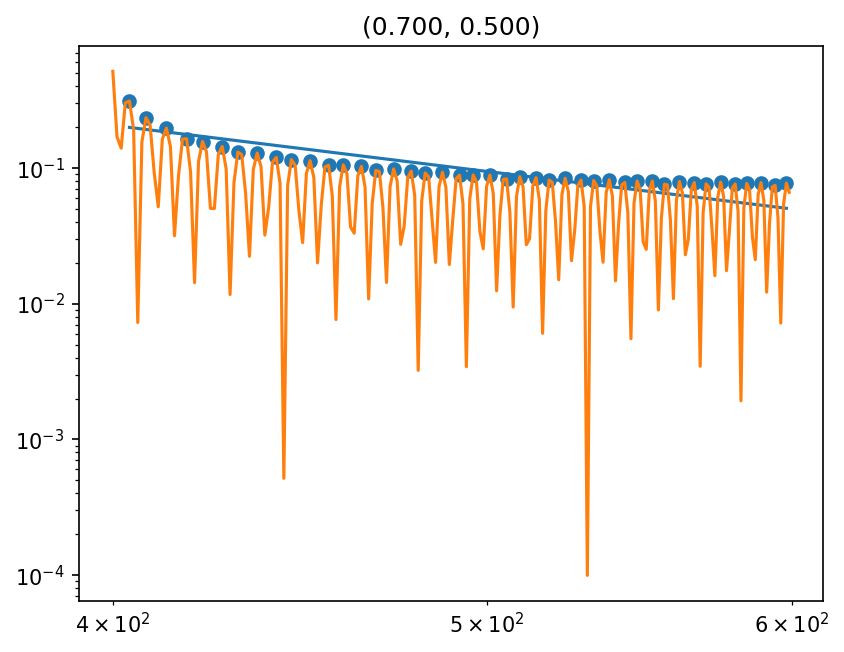

 17%|█▋        | 1/6 [00:00<00:02,  2.01it/s]

43
43


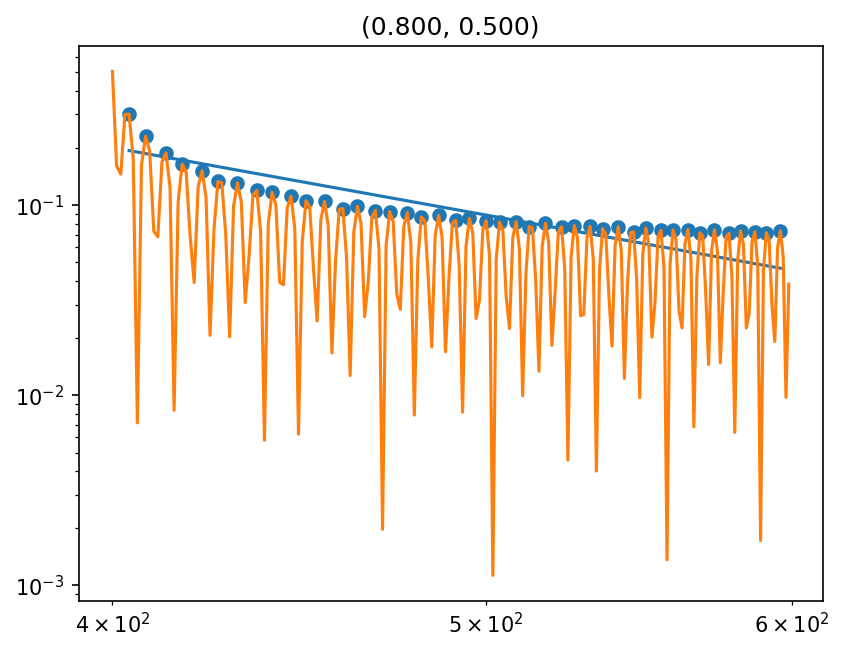

 33%|███▎      | 2/6 [00:00<00:01,  2.12it/s]

44
44


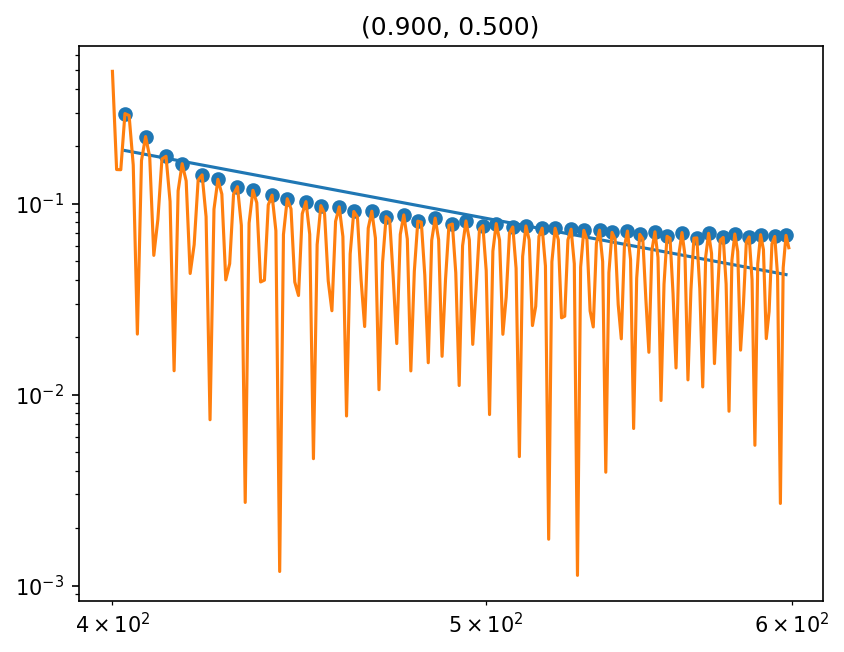

 50%|█████     | 3/6 [00:01<00:01,  1.88it/s]

44
44


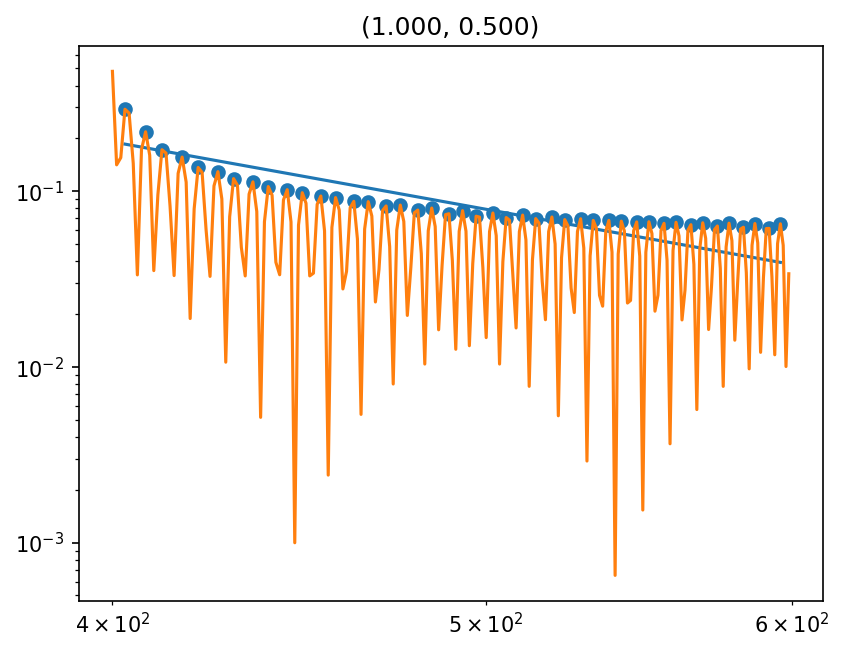

 67%|██████▋   | 4/6 [00:02<00:01,  1.89it/s]

45
45


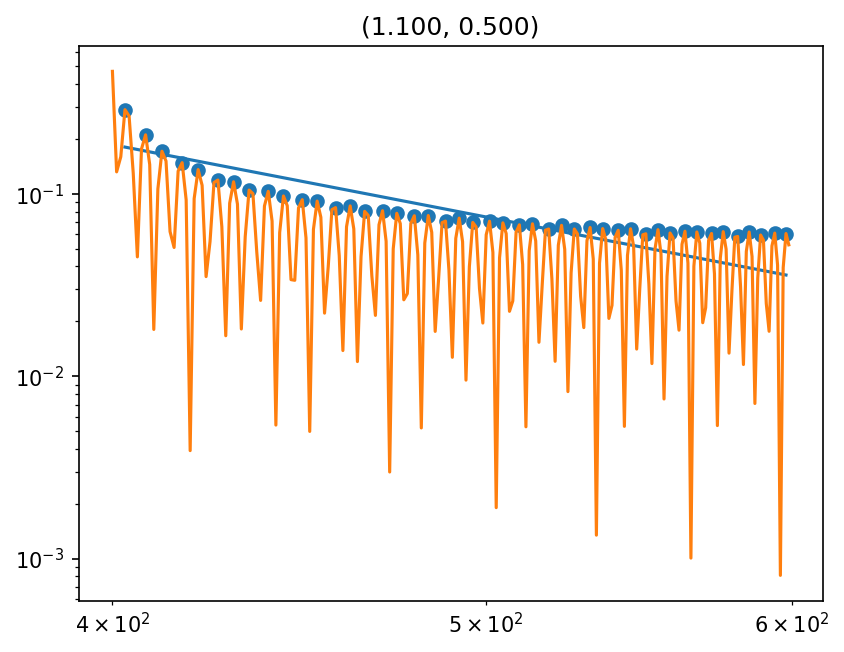

 83%|████████▎ | 5/6 [00:02<00:00,  1.99it/s]

45
45


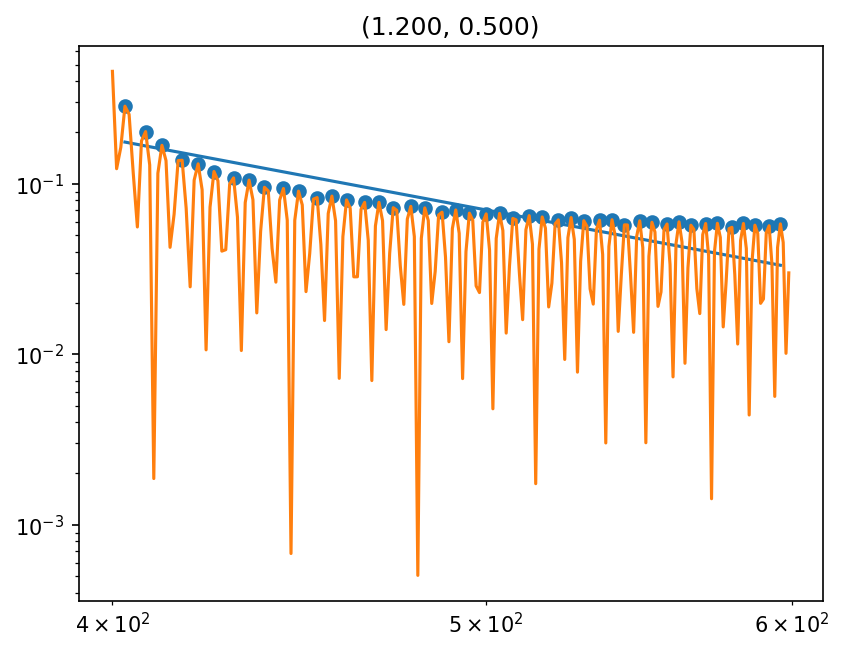

100%|██████████| 6/6 [00:02<00:00,  2.04it/s]


In [44]:
# correlation functions
from tqdm import tqdm
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

def linfun_loglog(x, A, b):
    return np.exp(b) * (x**A)

eta = []
ks = []

for i in tqdm(sorted(os.listdir(results))):
    loc = os.path.join(results, i)
    h, k = i.split("_")
    h = h[1:]

    _, op1 = np.loadtxt(os.path.join(loc, "X.txt")).T
    _, op2 = np.loadtxt(os.path.join(loc, "X.txt")).T
    connected_correlations = []
    dx = []

    for j ,corr in np.loadtxt(os.path.join(loc, "XX_corr.txt"), skiprows=1):
        if j < 0.25*L:
            dx.append(j+L//2)
            connected_correlations.append(corr)


    # for i, j, corr, _ in np.loadtxt(os.path.join(loc, "XX.txt"), skiprows=1):
    #     if i == L//2 and j > i:
    #         dx.append(j)
    #         connected_correlations.append(corr - (op1[int(i)] * op2[int(j)]))

    dx = np.array(dx)
    connected_correlations = np.array(connected_correlations)
    # find peaks and plot
    peaks, _ = find_peaks(np.abs(connected_correlations[:L//4]))
    dx_peaks = dx[peaks]
    print(len(dx_peaks))
    print(len(dx_peaks))
    corr_peaks = np.abs(connected_correlations)[peaks]

    if len(corr_peaks) < 2:
        continue
    popt, pcov = curve_fit(linfun_loglog, dx_peaks, corr_peaks)

    plt.scatter(dx_peaks, corr_peaks)
    plt.plot(dx[peaks], linfun_loglog(dx[peaks], *popt))
    plt.plot(dx, np.abs(connected_correlations), label=f"{h}, {k}, xi={-1/popt[0]}")
    # plt.legend()
    plt.title(f"({h}, {k})")
    plt.loglog()
    eta.append(-popt[0])
    ks.append(float(h))

    plt.show()



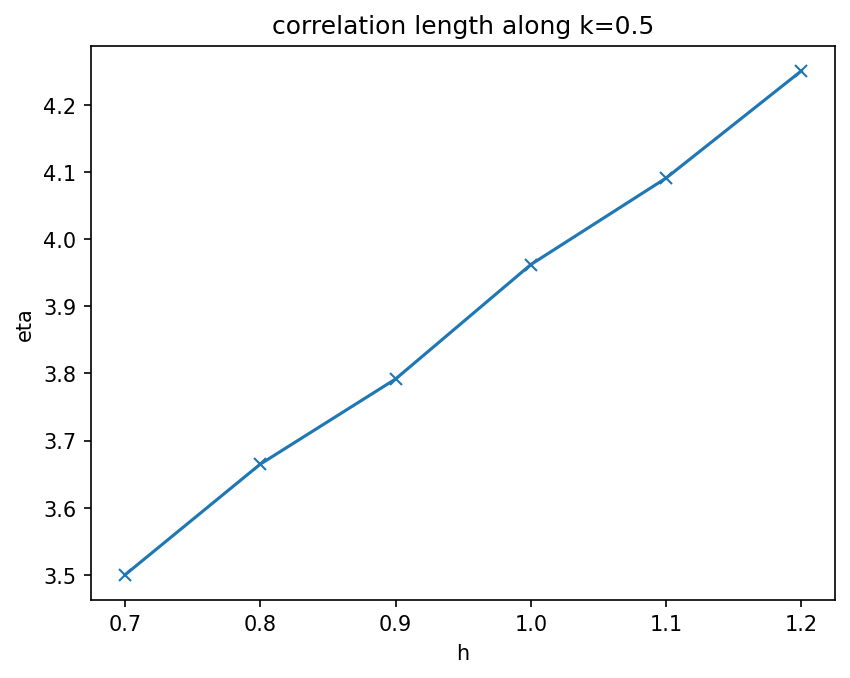

In [45]:
plt.plot(ks, eta, marker="x")
plt.title("correlation length along k=0.5")
plt.xlabel("h")
plt.ylabel("eta")
plt.show()

## Entanglement Entropy

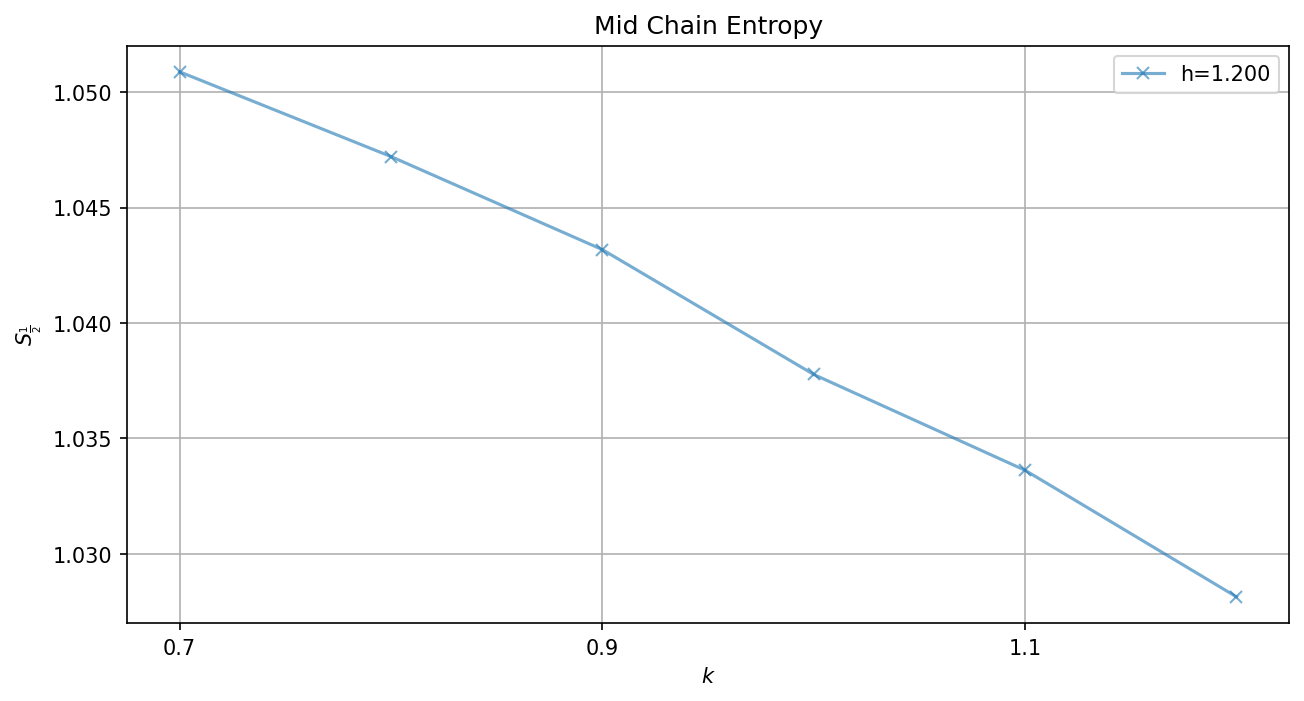

In [47]:
plt.figure(figsize=(10,5))

mid_chain_entropy = []
ks = []
for i in sorted(os.listdir(results)):
    loc = os.path.join(results, i)
    h, k = i.split("_")
    h = h[1:]
    x, _, S = np.loadtxt(os.path.join(loc, "S.txt")).T

    ks.append(float(h))
    mid_chain_entropy.append(S[L//2])
plt.plot(ks,mid_chain_entropy, marker="x", alpha=0.6, label=f"h={h}")
plt.xticks(ks[::2])

plt.title("Mid Chain Entropy")
plt.ylabel(r"$S_{\frac{1}{2}}$")
plt.xlabel(r"$k$")
plt.legend()
plt.grid()
plt.show()

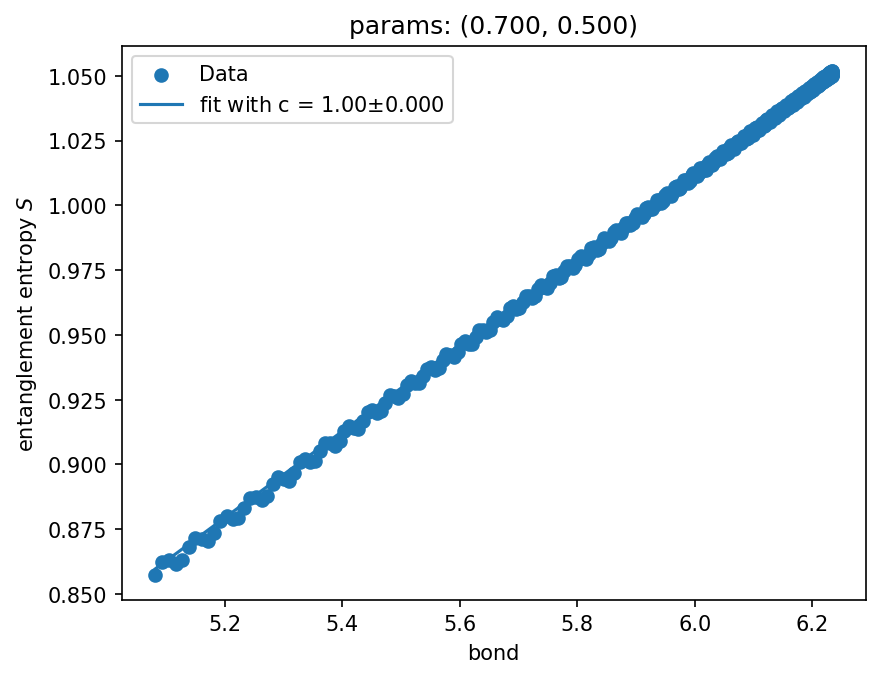

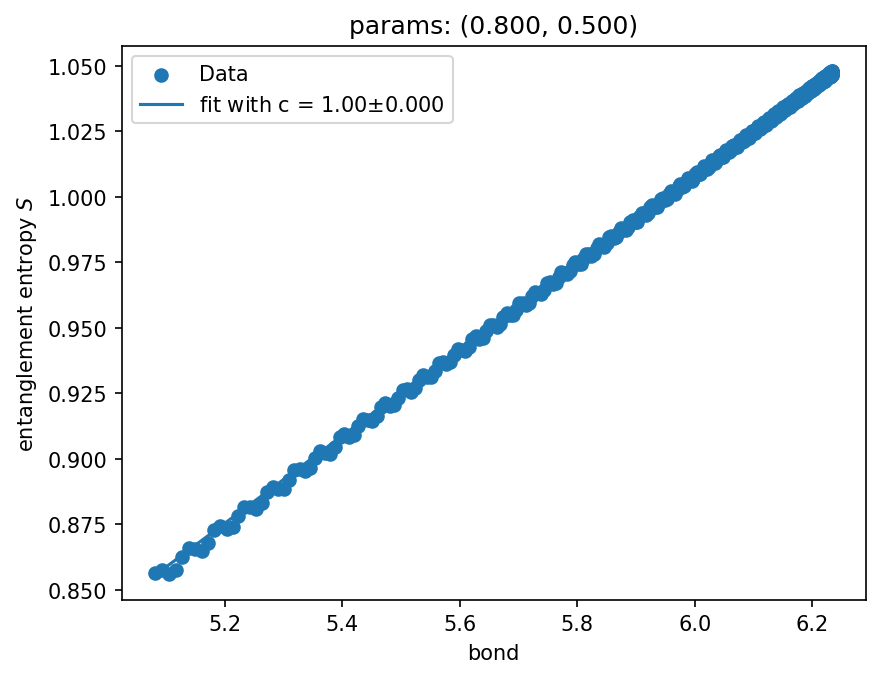

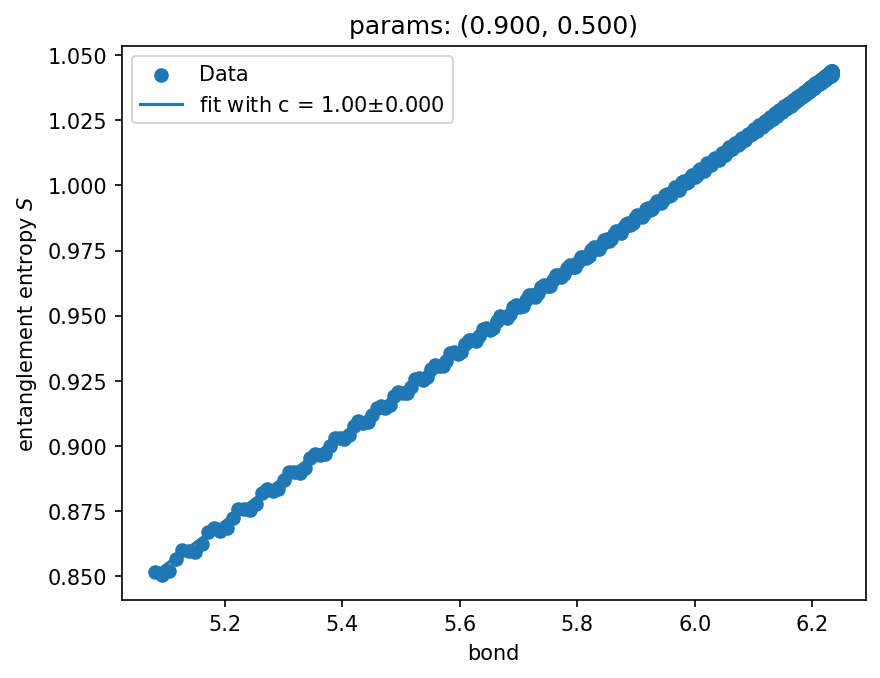

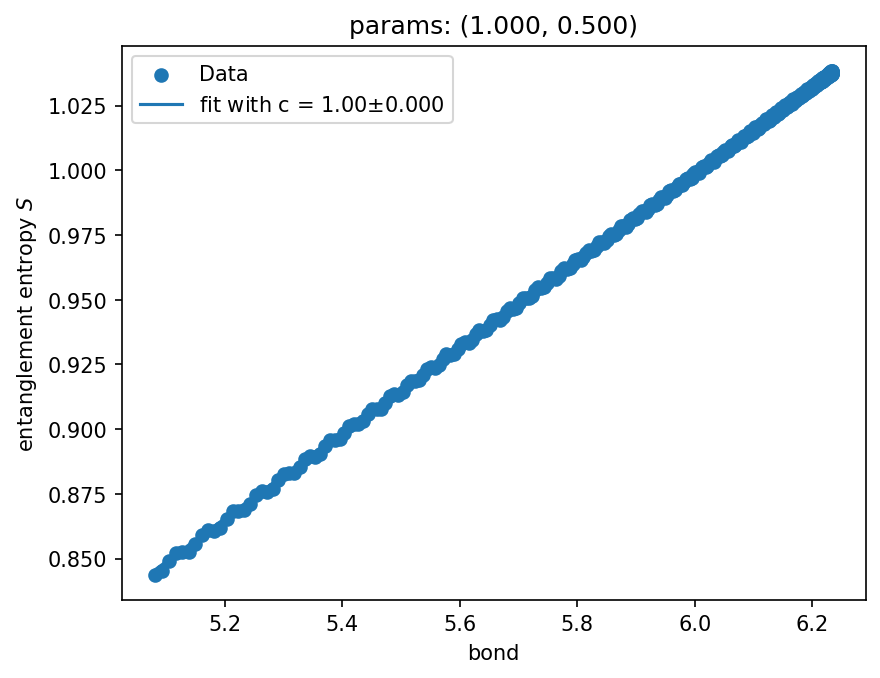

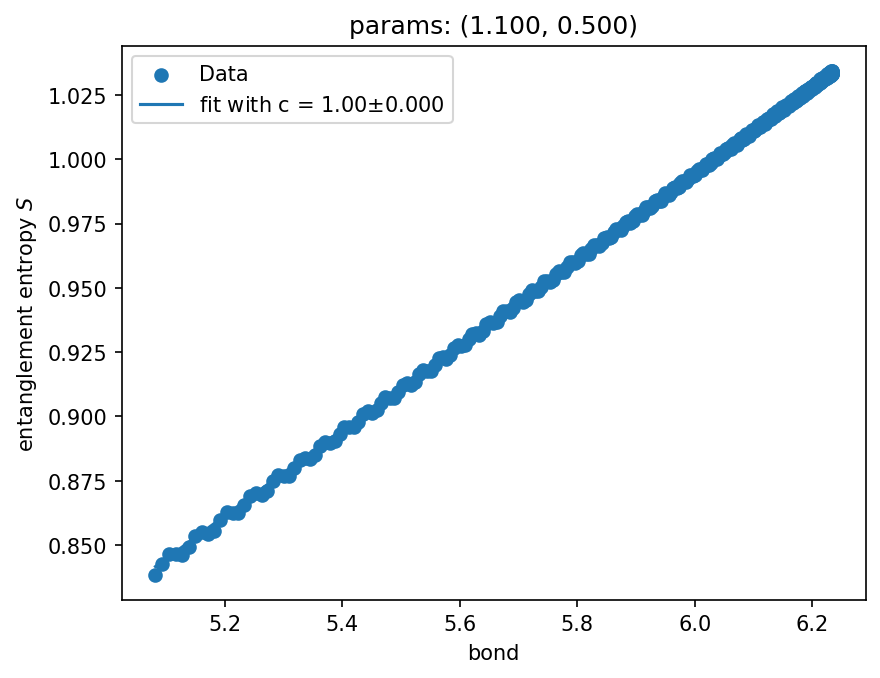

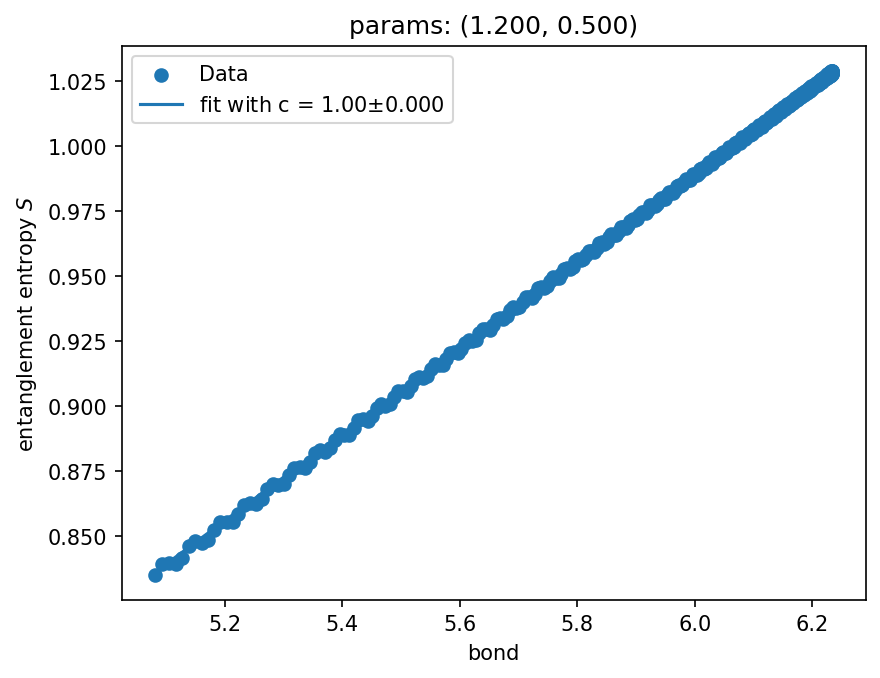

In [50]:
def linfun(x, c, consta):
    return (c/6) * x + consta

def conformal_distance(L, pos):
    return np.log((2*L/(np.pi) * np.sin((np.pi*pos)/L)))

c = []
c_err=[]
ks = []

for i in sorted(os.listdir(results)):
    h = i.split('_')[0][1:]
    k = i.split("_")[-1]
    loc = os.path.join(results, i)

    x, _, S = np.loadtxt(os.path.join(loc, "S.txt")).T

    conformal_bonds   = conformal_distance(L, x[L//2:-L//10])
    conformal_entropy = S[L//2:-L//10]
    peaks, _ = find_peaks(conformal_entropy)
    if len(conformal_entropy[peaks]) < 2:
        continue
    popt, pcov = curve_fit(linfun, conformal_bonds[peaks], conformal_entropy[peaks])

    # plt.scatter(bonds, S)

    # preform fit to extract the central charge

    plt.title(f"params: ({h}, {k})")
    plt.scatter(conformal_bonds, conformal_entropy, label=f"Data")
    plt.plot(conformal_bonds, linfun(conformal_bonds, *popt), label=f"fit with c = {popt[0]:.2f}"+r"$\pm$"+f"{pcov[0][0]:.3f}")
    plt.xlabel("bond")
    plt.ylabel("entanglement entropy $S$")
    plt.legend()
    plt.show()

    c.append(popt[0])
    c_err.append(pcov[0][0])
    ks.append(float(h))



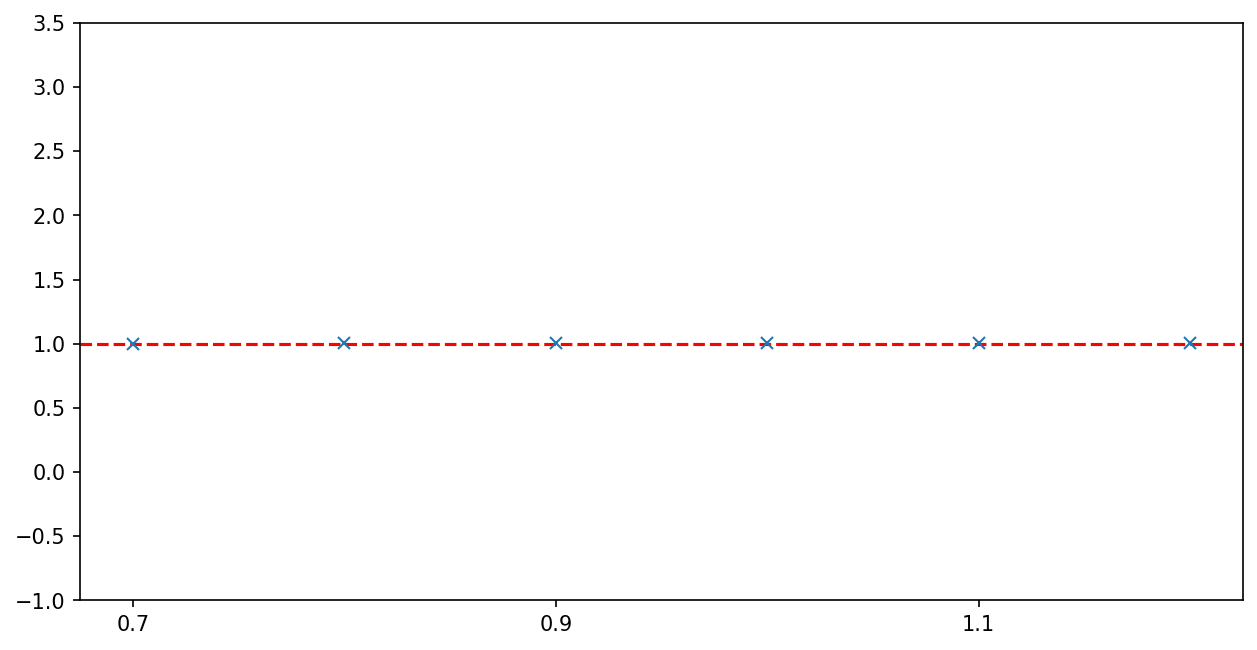

In [51]:
plt.figure(figsize=(10,5))

plt.errorbar(ks, c, c_err, marker='x', ls="none")
plt.axhline(1,c="red", ls="--",label=f"c=1")
plt.xticks(ks[::2])
plt.yticks([-1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5])
plt.show()

## Building the phase diagram

Use this to create python code for creating the big phase diagram at the end

Use plt.plot for the lines with marker for each point that you actually plotted
plt.fill_between for the colours

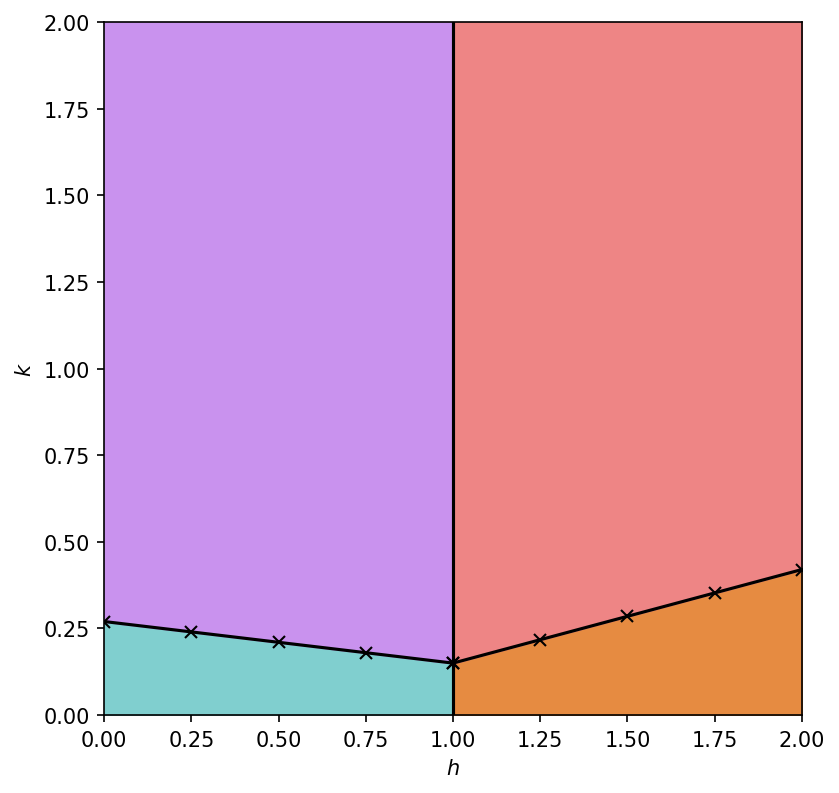

In [79]:
plt.figure(figsize=(6, 6))

values = [0, .25, .5, .75, 1]
first_order_transition = [0.27, .24, .21, .18, .15]

values_dual = [1, 1.25, 1.5, 1.75, 2]
first_order_transition_dual = [.15, .2175, .285, .3525, .42]

# primary phase transitions
plt.plot(values, first_order_transition, c="black", marker='x')
plt.plot(values_dual, first_order_transition_dual, c="black", marker="x")
plt.axvline(1, c="black")

# draw in phases
plt.fill_between(values, [0]*len(first_order_transition), first_order_transition, color="#7FCFCFFD")
plt.fill_between(values_dual, [0]*len(first_order_transition_dual), first_order_transition_dual, color="#E68B41")
plt.fill_between(values, first_order_transition, [2]*len(first_order_transition), color="#C992EE")
plt.fill_between(values_dual, first_order_transition_dual, [2]*len(first_order_transition_dual), color="#EE8585")

# add labels to diagram

# control the location of things
plt.xlim(0, 2)
plt.ylim(0, 2)
plt.xlabel(r"$h$")
plt.ylabel(r"$k$")
plt.show()

In [140]:
h_x, k = 0, 0
hours, minutes, seconds = 0, 0, 0
E_temp = [0]
chi = 200

print(f'Parameter ({h_x:.3f}, {k:.3f}) done !!!\n'
        f'Time elapsed: {hours:02}:{minutes:02}:{seconds:02}\n'
        f'Final Energy: {E_temp[-1]}\n'
        f'Final bond dimension: {chi}\n')
print(f'Parameter ({h_x:.3f}, {k:.3f}) done !!!\n'
        f'Time elapsed: {hours:02}:{minutes:02}:{seconds:02}\n'
        f'Final Energy: {E_temp[-1]}\n'
        f'Final bond dimension: {chi}\n')

Parameter (0.000, 0.000) done !!!
Time elapsed: 00:00:00
Final Energy: 0
Final bond dimension: 200

Parameter (0.000, 0.000) done !!!
Time elapsed: 00:00:00
Final Energy: 0
Final bond dimension: 200



### Calculate lines of incommensurability

We want lines of incommensurability across the following values:
$$ h = [0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], $$
$$ q = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]$$

In other words, we will have 6 lines of 9 points to determine the flow of incommensurability.

This means that we will need to send 9 simulations to the cluster of 0 < k < 3.


In [ ]:
# At the moment, just running 0.4, 0.8, 1.2, 1.6 ://
